# Fashion MNIST classification (Keras) with CNNs

## Libraries and constants

In [ ]:
import gc
import os

os.environ["KERAS_BACKEND"] = "torch"
import functools

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from utils import plot_loss_acc_per_ep, seed_everything

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Overview

This is a continuation of [module 12](https://github.com/jackyurchiksparrow/GO_IT_courses/blob/main/goit-ds-hw-12/main.ipynb), so the EDA is expected to have been done there.

## Data import

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

### Data representation, data split

In [ ]:
class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray):
        self.data = torch.from_numpy(data).clone().float()      # pixels to floats to be able to normalize later
        self.targets = torch.from_numpy(targets).clone().int()  # class labels are integers (0-9)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        return img, target

In [5]:
X_train_writable = X_train.copy()
y_train_writable = y_train.copy()

X_test_writable = X_test.copy()
y_test_writable = y_test.copy()

In [6]:
full_train_ds  = FashionMNISTDataset(X_train_writable, y_train_writable)
test_ds  = FashionMNISTDataset(X_test_writable, y_test_writable)

# Split train into train/validation (90/10)
train_size = int(0.9 * len(X_train))
val_size = len(full_train_ds) - train_size

train_ds, valid_ds = random_split(
    dataset=full_train_ds,
    lengths=[train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [7]:
print(f"Train: {len(train_ds)}, Validation: {len(valid_ds)}, Test: {len(test_ds)}")

Train: 54000, Validation: 6000, Test: 10000


## Creating and testing loaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(valid_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [9]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([1024, 28, 28])
Targets batch shape: torch.Size([1024])
Images data type   : torch.float32
Targets data type  : torch.int32
Targets in batch   : tensor([9, 3, 3,  ..., 3, 6, 6], dtype=torch.int32)


## Data normalization

The choice of the z-score normalization here is rather arbitrary here, a universal default. For faster convergence with pixel data we might have chosen zero-centered min-max $[-1,1]$.

In [10]:
# Calculate the whole dataset's mean and std in batches (not needed to do it in batches for such a small dataset though)
# (z-score normalization)
n = 0; s = 0.0; ss = 0.0
for x, _ in train_loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()

mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5
variance_ds = std_ds ** 2

# Hardcode the stats into Keras
normalizer = keras.layers.Normalization(
    axis=None,
    mean=mean_ds,
    variance=variance_ds,
)

## Task 1

### Model architecting

We are asked to engineer model for the task. The reference table dor decision making:

| Year | Model                    | Total Params | FC-head Params | % in FC head | Typical block                                               | Conv layers | ImageNet acc (top 1) | ImageNet acc (top 5) |
| ---- | ------------------------ | ------------ | -------------- | ------------ | ----------------------------------------------------------- | ----------- | -------------------- | -------------------- |
| 1998 | LeNet-5                  | ~61,700      | ~59,100        | ~96%         | conv -> tanh -> avgpool                                     | 2           | ~99.0 (MNIST)        | —                    |
| 2012 | AlexNet                  | ~61,100,000  | ~58,600,000    | ~96%         | conv -> ReLU -> maxpool (LRN early)                         | 5           | 56.5                 | 79.1                 |
| 2014 | VGG-16                   | ~138,400,000 | ~123,600,000   | ~89%         | [conv3x3 -> ReLU] x2-3 -> maxpool                           | 13          | 71.6                 | 90.4                 |
| 2014 | VGG-19                   | ~143,700,000 | ~123,600,000   | ~86%         | [conv3x3 -> ReLU] x2-4 -> maxpool                           | 16          | 72.4                 | 90.9                 |
| 2015 | ResNet-18                | ~11,700,000  | ~513,000       | ~4%          | [conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU     | 20          | 69.8                 | 89.1                 |
| 2015 | ResNet-34                | ~21,800,000  | ~513,000       | ~2%          | [conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU     | 36          | 73.3                 | 91.4                 |

The first question is *what's the priority*. It is **accuracy**.

*How many convolutions do I need* for best accuracy **at least**? Because we want the most efficient model.

Once we establish that, we will be assessing the model's performance empirically and adjust. Underfitting - try more layers, overfitting - fewer/regularization.

**Contemplation**: `Le-Net` is the simplest option, but its 2 layers might underperform, although it was specifically designed for datasets like this, namely numerical MNIST. We know for a fact that Fashion-MNIST is more complex, the docs say so. The next models by architectural simplicity are `AlexNet` with 5 convolutions, `VGG` (13-16 convolutions) and `ResNet` (20 convolutions). `ResNet` is the most modern among them. Its accuracy is on point. We are going to use it as a benchmark and build a teeny-tiny version of it. The typical block in the architecture is `[conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU`. Given the complexity of the data, we won't need skip connections. The number of convolutions for such datasets shouldn't be too far from `Le-Net`'s then, say 4-10. If this under-/overfits empirically, we will be increasing/reducing them further.

In [ ]:
def cnn_block(n, activation_type="relu"):
    """Creates a sequential block consisting of Conv2D -> BatchNorm -> Activation (ResNet-like)."""
    return keras.Sequential([
        keras.layers.Conv2D(
            filters=n,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="valid",    # padding=0
            use_bias=False,     # no use in bias before BatchNorm
            activation=None,    # no use in activation before BatchNorm
        ),
        keras.layers.BatchNormalization(),
        keras.layers.Activation(activation_type),
    ])

def build_model(n, num_classes: int = 10, activation_type: str = "relu"):
    # 1. Define Input
    inputs = keras.layers.Input(shape=(28, 28))         # current inputs are 28x28 first
    x = keras.layers.Reshape((28,28,1))(inputs)         # explicitly add the channel dimension (28,28) -> (28,28,1)

    # 2. Normalization Layer. Shape after: (28,28)
    x = normalizer(x)

    # 3. First CNN block. Shape after: (n,26,26)
    x = cnn_block(n, activation_type)(x)

    # 4. Max Pooling. Shape after: (n,13,13)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # 5. Second CNN block. Shape after: (2n,11,11)
    x = cnn_block(2 * n, activation_type)(x)

    # 6. Third CNN block. Shape after: (4n,9,9)
    x = cnn_block(4 * n, activation_type)(x)

    # 7. Fourth CNN block. Shape after: (6n,7,7)
    x = cnn_block(6 * n, activation_type)(x)

    # 8. Flatten. Shape after: (1, 6nx7x7)
    x = keras.layers.Flatten()(x)

    # 9. Dense Classification Layer
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    # Construct the final model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [18]:
model = build_model(n=32, num_classes=10, activation_type="relu")
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_52CLONE            │ (None, 28, 28, 1)      │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 26, 26, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 11, 11, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 9, 9, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ (None, 7, 7, 192)      │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        94,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,386 (1.56 MB)

 Trainable params: 408,554 (1.56 MB)

 Non-trainable params: 832 (3.25 KB)

The last fully-connected layer is `94,090` params for $n=32$. which is `23%` of all parameters, not critical given the reference table's.

This is what I picked up on the web: 
> "The creators of ResNet (and a slightly earlier network called Network In Network) realized flattening was a massive waste of parameters that caused severe overfitting". 

Instead of flattening, they introduced Global Average Pooling (GAP)."

I am following their approach.

In [ ]:
def build_model(n, num_classes: int = 10, activation_type: str = "relu"):
    # 1. Define Input. Shape: (28,28,1) - grayscale
    inputs = keras.layers.Input(shape=(28, 28))         # current inputs are 28x28 first
    x = keras.layers.Reshape((28,28,1))(inputs)         # explicitly add the channel dimension (28,28) -> (28,28,1)

    # 2. Normalization Layer. Shape after: (28,28)
    x = normalizer(x)

    # 3. First CNN block. Shape after: (n,26,26)
    x = cnn_block(n, activation_type)(x)

    # 4. Max Pooling. Shape after: (n,13,13)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # 5. Second CNN block. Shape after: (2n,11,11)
    x = cnn_block(2 * n, activation_type)(x)

    # 6. Third CNN block. Shape after: (4n,9,9)
    x = cnn_block(4 * n, activation_type)(x)

    # 7. Fourth CNN block. Shape after: (6n,7,7)
    x = cnn_block(6 * n, activation_type)(x)

    # 8. Average pooling. Shape after: (6n)
    x = keras.layers.GlobalAveragePooling2D()(x)

    # 9. Dense Classification Layer
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    # Construct the final model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [14]:
model = build_model(n=32, num_classes=10, activation_type="relu")
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 26, 26, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 11, 11, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 9, 9, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 7, 7, 192)      │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317,226 (1.21 MB)

 Trainable params: 316,394 (1.21 MB)

 Non-trainable params: 832 (3.25 KB)

That's a massive parameter drop (48 times fewer params) in the final fully connected:

$\text{before: } 94,090 \quad \text{after: } 1,930$

### Training

In [ ]:
def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader

def debug_tuner(tuner):
    trial_list = []

    # Loop through all trials stored in the tuner's oracle
    for trial_id, trial in tuner.oracle.trials.items():
        row = {
            "trial_id": trial_id,
            "score": trial.score,  # This will be our val_accuracy or val_loss
            "best_epoch": trial.best_step + 1,   # best epoch from early stopping
        }
        # Unpack and add the specific hyperparameters chosen for this trial
        row.update(trial.hyperparameters.values)
        trial_list.append(row)

    # Convert to DataFrame
    df_results = pd.DataFrame(trial_list)

    # Sort them so the best-performing models are at the top
    # (Change ascending=True if we are optimizing for loss instead of accuracy)
    df_results = df_results.sort_values(by="score", ascending=False)

    # Display the neat table!
    return df_results

In [ ]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)    # same init for every trial
    torch_gen.manual_seed(RANDOM_SEED)          # same shuffle order for every trial

    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "leaky_relu", "gelu", "silu"])        # 4 options
    units = hp.Choice("units", values=[8, 16, 32, 64])                                  # 4 options

    mdl = build_model(n=units, activation_type=activation)

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

Total combinations: $4 \times 4 \times 4 \times 3 = 192$. Exploring $15$:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="task_1_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder (first tuning run) in /fashion_mnist/task_1_tuning/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 25s]
val_accuracy: 0.737666666507721

Best val_accuracy So Far: 0.9226666688919067
Total elapsed time: 00h 43m 04s
{'activation': 'gelu', 'units': 64, 'lr': 0.0005, 'optimizer': 'adam'}


In [ ]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr,optimizer
13,13,0.922667,gelu,64,0.0005,adam
10,10,0.913833,relu,16,0.0010,adam
1,01,0.911000,silu,16,0.0010,adam
8,08,0.909500,silu,16,0.0005,rmsprop
3,03,0.895667,silu,8,0.0050,adam
12,12,0.888000,relu,8,0.0005,rmsprop
6,06,0.884000,relu,8,0.0010,rmsprop
2,02,0.880500,leaky_relu,8,0.0050,sgd
0,00,0.879500,gelu,8,0.0005,adam
11,11,0.878500,silu,8,0.0005,adam


New best score compared to the dense model from module 12: `0.922667`: `activation: gelu, units=64, optimizer=adam, lr=0.0005`.

Conclusions to shrink down the search space:
- higher units almost always result in higher score (removing `units=8`)
- `optimizer=sgd` didn't score enough, removed

In [ ]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)
    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "leaky_relu", "gelu", "silu"])        # 4 options
    units = hp.Choice("units", values=[16, 32, 64])                                     # 3 options

    mdl = build_model(n=units, activation_type=activation)

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])         # 2 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

Total combinations: $4 \times 3 \times 4 \times 2 = 96$. Exploring next $15$:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15+15,                           # another 15
    directory="task_1_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue the same search keeping track of old combinations
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 06m 27s]
val_accuracy: 0.9048333168029785

Best val_accuracy So Far: 0.9223333597183228
Total elapsed time: 00h 57m 23s
{'activation': 'gelu', 'units': 64, 'lr': 0.0005, 'optimizer': 'adam'}


In [ ]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr,optimizer
12,12,0.922333,gelu,64,0.0005,adam
0,00,0.912333,gelu,16,0.0005,adam
9,09,0.911833,relu,32,0.0010,adam
1,01,0.910833,silu,32,0.0010,adam
4,04,0.910667,silu,32,0.0005,adam
3,03,0.909500,silu,16,0.0050,adam
8,08,0.909333,silu,16,0.0005,rmsprop
7,07,0.907667,silu,32,0.0005,rmsprop
5,05,0.906333,relu,16,0.0010,rmsprop
10,10,0.905333,silu,16,0.0005,adam


We've found the same best setup `activation: gelu, units=64, optimizer=adam, lr=0.0005`, which gave `0.92233` this time.

**In short**: I forgot to fix the seeds for convolutions AND tuner's init weights AND to set `overwrite=False` first.

Conclusions to shrink down the search space further:
- optimizer: definitely `adam`
- removing `leaky_relu` since it wasn't among higher scores even with $n=32$
- exploring different learning rates (log-scale)

In [ ]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)   # resets python/numpy/torch-global -> weight init
    torch_gen.manual_seed(RANDOM_SEED)         # resets the DataLoader's shuffle stream -> data order

    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "gelu", "silu"])        # 3 options
    units = hp.Choice("units", values=[16, 32, 64])                       # 3 options

    mdl = build_model(n=units, activation_type=activation)

    # hp.Float with sampling="log" for continuous logarithmic scaling
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15+15+15,
    directory="task_1_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                            # continue
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 45s]
val_accuracy: 0.9129999876022339

Best val_accuracy So Far: 0.9253333210945129
Total elapsed time: 00h 59m 22s
{'activation': 'relu', 'units': 64, 'lr': 0.000505466655750672}


In [ ]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr
1,01,0.925333,relu,64,0.000505
3,03,0.921000,relu,64,0.001715
11,11,0.919833,gelu,32,0.003965
7,07,0.916500,gelu,32,0.000675
9,09,0.915000,silu,64,0.000444
6,06,0.913500,relu,32,0.007178
14,14,0.913000,silu,16,0.003829
8,08,0.908667,relu,16,0.003043
2,02,0.908500,gelu,16,0.000989
13,13,0.908500,gelu,16,0.000982


New best score: `0.925333`: `{'activation': 'relu', 'units': 64, 'lr': 0.000505466655750672}`

- Finally confirmed the more neurons, the higher the accuracy $\rightarrow$ sticking to `64`
- Choosing `relu` as the top scored setup and setting the `lr` fixed to its best value currently.

There's ultimately no reason to adjust batch_size as it will change the gradient dynamics, requiring further re-tuning of other parameters.

### Fine-tuning

The best model after tuning:

In [ ]:
def build_model(lr: float = 0.000505466655750672):
    inputs = keras.layers.Input(shape=(28, 28))
    x = keras.layers.Reshape((28,28,1))(inputs)

    x = normalizer(x)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

tuned_model = build_model()
tuned_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 26, 26, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 11, 11, 128)    │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 9, 9, 256)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 7, 7, 384)      │       886,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,261,133 (4.81 MB)

 Trainable params: 1,259,466 (4.80 MB)

 Non-trainable params: 1,667 (6.51 KB)

Exploring the training process of the best model visually:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
tuned_model = build_model()

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step - accuracy: 0.8374 - loss: 0.4544 - val_accuracy: 0.8532 - val_loss: 0.3997
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.8914 - loss: 0.3024 - val_accuracy: 0.8840 - val_loss: 0.3194
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 48s 112ms/step - accuracy: 0.9063 - loss: 0.2611 - val_accuracy: 0.8800 - val_loss: 0.3352
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9160 - loss: 0.2334 - val_accuracy: 0.8883 - val_loss: 0.3164
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.9229 - loss: 0.2136 - val_accuracy: 0.8777 - val_loss: 0.3515
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 104ms/step - accuracy: 0.9299 - loss: 0.1970 - val_accuracy: 0.9130 - val_loss: 0.2485
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.9351 - loss: 0.1809 - val_accuracy: 0.9090 - val_loss: 0.2640
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9398 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4544  val_loss=0.3997  train_acc=0.8374  val_acc=0.8532
Epoch  1: train_loss=0.3024  val_loss=0.3194  train_acc=0.8914  val_acc=0.8840
Epoch  2: train_loss=0.2611  val_loss=0.3352  train_acc=0.9063  val_acc=0.8800
Epoch  3: train_loss=0.2334  val_loss=0.3164  train_acc=0.9160  val_acc=0.8883
Epoch  4: train_loss=0.2136  val_loss=0.3515  train_acc=0.9229  val_acc=0.8777
Epoch  5: train_loss=0.1970  val_loss=0.2485  train_acc=0.9299  val_acc=0.9130
Epoch  6: train_loss=0.1809  val_loss=0.2640  train_acc=0.9351  val_acc=0.9090
Epoch  7: train_loss=0.1691  val_loss=0.2699  train_acc=0.9398  val_acc=0.9003
Epoch  8: train_loss=0.1553  val_loss=0.2776  train_acc=0.9444  val_acc=0.9032
Epoch  9: train_loss=0.1436  val_loss=0.2158  train_acc=0.9487  val_acc=0.9228
Epoch 10: train_loss=0.1313  val_loss=0.2538  train_acc=0.9535  val_acc=0.9120
Epoch 11: train_loss=0.1193  val_loss=0.2392  train_acc=0.9587  val_acc=0.9173
Epoch 

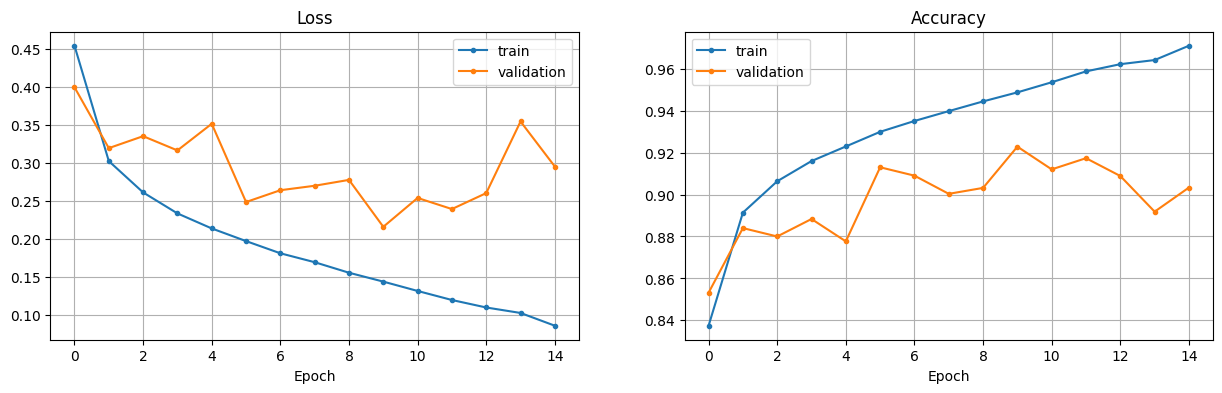

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Best here: `Epoch[9]: train_loss=0.1436  val_loss=0.2158  train_acc=0.9487  val_acc=0.9228`.

Now, we need to establish the best base learning rate before applying the schedulers. To fine-tune this, we want to set a linear bracket that goes slightly below and slightly above the tuned `lr=0.000505`.

In [ ]:
def build_model():
    inputs = keras.layers.Input(shape=(28, 28))
    x = keras.layers.Reshape((28,28,1))(inputs)
    x = normalizer(x)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    lr = hp.Float("lr", min_value=0.0003, max_value=0.0007, step=0.00005)   # 9 iterations (0.0007-0.0003)/0.00005 and 0.0003
    mdl = build_model()

    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="task1_fine_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,                 # start fresh (1st fine-tuning run)
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 9 Complete [00h 09m 33s]
val_accuracy: 0.925000011920929

Best val_accuracy So Far: 0.9268333315849304
Total elapsed time: 01h 24m 03s
{'lr': 0.0006000000000000001}


In [ ]:
debug_tuner(tuner)

,trial_id,score,lr
7,07,0.926833,0.00060
5,05,0.926000,0.00050
8,08,0.925000,0.00035
4,04,0.923500,0.00065
0,00,0.923000,0.00055
3,03,0.921667,0.00040
2,02,0.920667,0.00045
1,01,0.918000,0.00030
6,06,0.917833,0.00070


New best: `{'lr': 0.0006000000000000001}, val_accuracy: 0.925000011920929`, assessing the plot to properly set up the schedulers:

The best model now:

In [ ]:
def build_model():
    inputs = keras.layers.Input(shape=(28, 28))
    x = keras.layers.Reshape((28,28,1))(inputs)
    x = normalizer(x)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0006), # the newly discovered lr
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

Observing the learning curves of the newly obtained best model:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
tuned_model = build_model()

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 49s 113ms/step - accuracy: 0.8383 - loss: 0.4505 - val_accuracy: 0.8437 - val_loss: 0.4224
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 50s 116ms/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8838 - val_loss: 0.3227
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 47s 108ms/step - accuracy: 0.9066 - loss: 0.2597 - val_accuracy: 0.8807 - val_loss: 0.3352
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 56s 130ms/step - accuracy: 0.9163 - loss: 0.2323 - val_accuracy: 0.8895 - val_loss: 0.3124
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 66s 153ms/step - accuracy: 0.9228 - loss: 0.2129 - val_accuracy: 0.8767 - val_loss: 0.3596
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 63s 146ms/step - accuracy: 0.9304 - loss: 0.1959 - val_accuracy: 0.9117 - val_loss: 0.2543
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.9352 - loss: 0.1800 - val_accuracy: 0.9040 - val_loss: 0.2768
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 71s 163ms/step - accuracy: 0.9392 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4505  val_loss=0.4224  train_acc=0.8383  val_acc=0.8437
Epoch  1: train_loss=0.3012  val_loss=0.3227  train_acc=0.8913  val_acc=0.8838
Epoch  2: train_loss=0.2597  val_loss=0.3352  train_acc=0.9066  val_acc=0.8807
Epoch  3: train_loss=0.2323  val_loss=0.3124  train_acc=0.9163  val_acc=0.8895
Epoch  4: train_loss=0.2129  val_loss=0.3596  train_acc=0.9228  val_acc=0.8767
Epoch  5: train_loss=0.1959  val_loss=0.2543  train_acc=0.9304  val_acc=0.9117
Epoch  6: train_loss=0.1800  val_loss=0.2768  train_acc=0.9352  val_acc=0.9040
Epoch  7: train_loss=0.1685  val_loss=0.2914  train_acc=0.9392  val_acc=0.8908
Epoch  8: train_loss=0.1546  val_loss=0.2492  train_acc=0.9442  val_acc=0.9130
Epoch  9: train_loss=0.1417  val_loss=0.2129  train_acc=0.9494  val_acc=0.9268
Epoch 10: train_loss=0.1301  val_loss=0.2678  train_acc=0.9532  val_acc=0.9047
Epoch 11: train_loss=0.1177  val_loss=0.2309  train_acc=0.9584  val_acc=0.9197
Epoch 

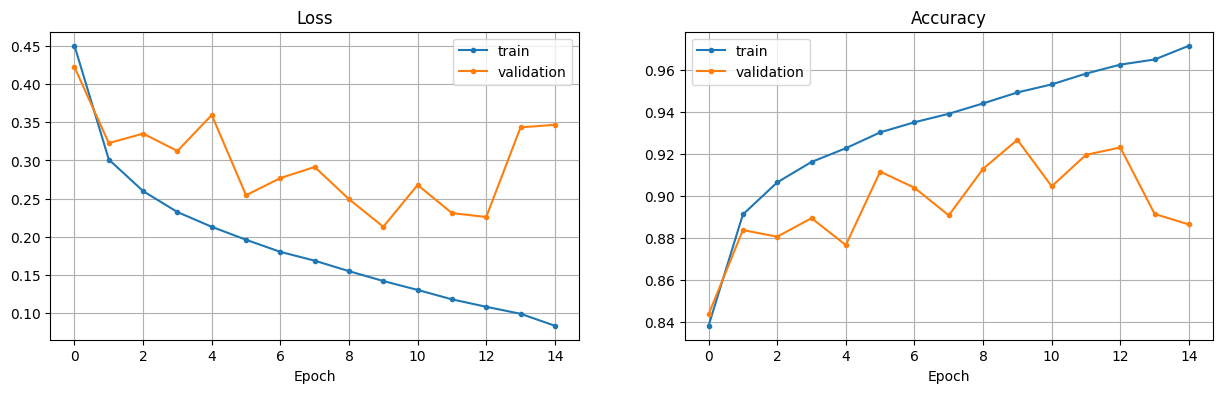

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Epoch[9] is confirmed to be the most optimal: `Epoch  9: train_loss=0.1417  val_loss=0.2129  train_acc=0.9494  val_acc=0.9268`

Saving the current best:

In [ ]:
tuned_model.save("task1_fine_tuned_before_ls_schedulers.keras")

#### Learning rate schedulers

In [ ]:
# redeclare for keras tuner
def build_model(lr):
    inputs = keras.layers.Input(shape=(28, 28))
    x = keras.layers.Reshape((28,28,1))(inputs)
    x = normalizer(x)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_rand_search_model(hp, epochs):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    name = hp.Choice("scheduler", [
            "constant",          # baseline: flat 0.0006, for comparison
            "custom_stairs",     # custom staircase
            "exponential",       # smooth *0.9 per epoch
            "cosine",            # glide 0.0006 -> ~0 over the whole run
            "cosine_restarts",   # cosine, but periodically jumps back up (escapes basins)
            "inverse_time",      # 1/(1+decay*t)
            "piecewise",         # gentler staircase: /10 at epoch 10, /100 at 15
        ])

    base  = 0.0006
    steps = len(train_loader)          # batches per epoch
    S     = keras.optimizers.schedules

    if name == "custom_stairs":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 3, steps * 7, steps * 10],
                                      values=[base, 1e-4, 1e-5, 1e-6])
    elif name == "exponential":
        lr = S.ExponentialDecay(base, decay_steps=steps, decay_rate=0.9)
    elif name == "cosine":
        lr = S.CosineDecay(base, decay_steps=steps * epochs)
    elif name == "cosine_restarts":
        lr = S.CosineDecayRestarts(base, first_decay_steps=steps * 10)
    elif name == "inverse_time":
        lr = S.InverseTimeDecay(base, decay_steps=steps, decay_rate=0.5)
    elif name == "piecewise":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15],
                                      values=[base, base * 0.1, base * 0.01])
    else: # "constant"
        lr = base

    model = build_model(lr=lr)
    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

sched_tuner = kt.GridSearch(
    functools.partial(build_rand_search_model, epochs=60),   # more epochs + functools to send an additional argument
    objective="val_accuracy",
    directory="fine_tuning_lr_schedulers",
    project_name="fashion_mnist_schedulers",
    seed=RANDOM_SEED,
    overwrite=True,
)
sched_tuner.search(x=train_loader, validation_data=valid_loader, epochs=60,   # more epochs
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, # more patience
                                                            restore_best_weights=True, verbose=1)],
                   verbose=1, shuffle=False)

Trial 7 Complete [00h 28m 48s]
val_accuracy: 0.9411666393280029

Best val_accuracy So Far: 0.9411666393280029
Total elapsed time: 03h 34m 24s


In [ ]:
debug_tuner(sched_tuner)

,trial_id,score,scheduler
6,0006,0.941167,piecewise
4,0004,0.935333,cosine_restarts
1,0001,0.934500,custom_stairs
2,0002,0.934167,exponential
5,0005,0.928833,inverse_time
0,0000,0.919500,constant
3,0003,0.918000,cosine


New absolute best validation accuracy score: `0.941167`, `scheduler=piecewise`.

### Best final model and evaluation

In [ ]:
def build_final_model(base_lr: float, steps: int):
    inputs = keras.layers.Input(shape=(28, 28))
    x = keras.layers.Reshape((28,28,1))(inputs)
    x = normalizer(x)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    lr = keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15], values=[base_lr, base_lr * 0.1, base_lr * 0.01])
    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
steps = len(train_loader)
model = build_final_model(base_lr=0.0006, steps=steps)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=60,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 69s 160ms/step - accuracy: 0.8383 - loss: 0.4505 - val_accuracy: 0.8437 - val_loss: 0.4224
Epoch 2/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8838 - val_loss: 0.3227
Epoch 3/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.9066 - loss: 0.2597 - val_accuracy: 0.8807 - val_loss: 0.3352
Epoch 4/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 70s 163ms/step - accuracy: 0.9163 - loss: 0.2323 - val_accuracy: 0.8895 - val_loss: 0.3124
Epoch 5/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 70s 161ms/step - accuracy: 0.9228 - loss: 0.2129 - val_accuracy: 0.8767 - val_loss: 0.3596
Epoch 6/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 70s 162ms/step - accuracy: 0.9304 - loss: 0.1959 - val_accuracy: 0.9117 - val_loss: 0.2543
Epoch 7/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 68s 158ms/step - accuracy: 0.9352 - loss: 0.1800 - val_accuracy: 0.9040 - val_loss: 0.2768
Epoch 8/60
432/432 ━━━━━━━━━━━━━━━━━━━━ 68s 158ms/step - accuracy: 0.9392 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4505  val_loss=0.4224  train_acc=0.8383  val_acc=0.8437
Epoch  1: train_loss=0.3012  val_loss=0.3227  train_acc=0.8913  val_acc=0.8838
Epoch  2: train_loss=0.2597  val_loss=0.3352  train_acc=0.9066  val_acc=0.8807
Epoch  3: train_loss=0.2323  val_loss=0.3124  train_acc=0.9163  val_acc=0.8895
Epoch  4: train_loss=0.2129  val_loss=0.3596  train_acc=0.9228  val_acc=0.8767
Epoch  5: train_loss=0.1959  val_loss=0.2543  train_acc=0.9304  val_acc=0.9117
Epoch  6: train_loss=0.1800  val_loss=0.2768  train_acc=0.9352  val_acc=0.9040
Epoch  7: train_loss=0.1685  val_loss=0.2914  train_acc=0.9392  val_acc=0.8908
Epoch  8: train_loss=0.1546  val_loss=0.2492  train_acc=0.9442  val_acc=0.9130
Epoch  9: train_loss=0.1417  val_loss=0.2129  train_acc=0.9494  val_acc=0.9268
Epoch 10: train_loss=0.0945  val_loss=0.1816  train_acc=0.9699  val_acc=0.9375
Epoch 11: train_loss=0.0839  val_loss=0.1784  train_acc=0.9745  val_acc=0.9360
Epoch 

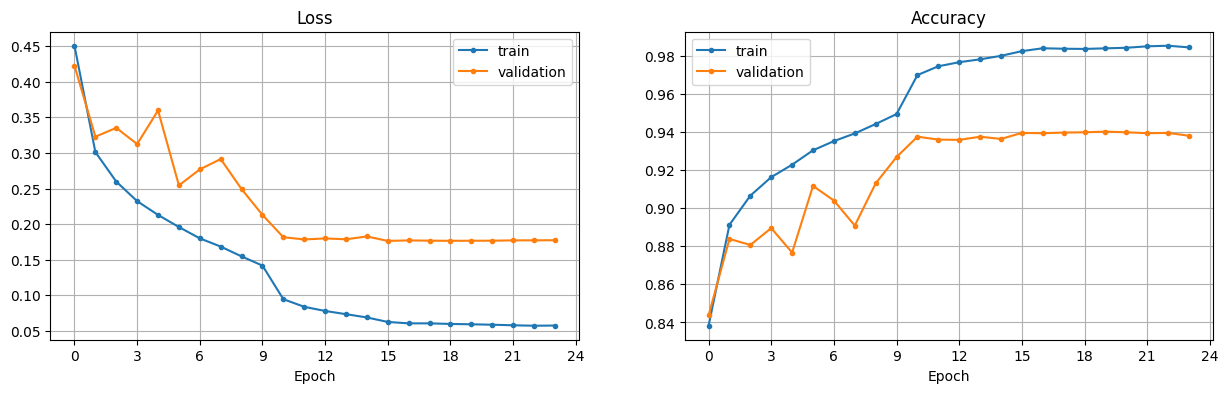

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

The most optimal: Epoch[15] - `train_loss=0.0626  val_loss=0.1764  train_acc=0.9824  val_acc=0.9395`

In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("task1_final_train.keras")

# --- Load ---
loaded = keras.models.load_model("task1_final_train.keras")

Fit on full train before assessing on test:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

full_train_loader = DataLoader(full_train_ds, batch_size=125, shuffle=True, generator=torch_gen)
steps = len(full_train_loader)          # batches per epoch (for lr scheduler)
model = build_final_model(base_lr=0.0006, steps=steps)

history = model.fit(
    x=full_train_loader,
    epochs=16,
    verbose=1,
    shuffle=False,
)

Epoch 1/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.8399 - loss: 0.4425
Epoch 2/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8949 - loss: 0.2935
Epoch 3/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9086 - loss: 0.2554
Epoch 4/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9170 - loss: 0.2288
Epoch 5/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9250 - loss: 0.2090
Epoch 6/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9317 - loss: 0.1910
Epoch 7/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9354 - loss: 0.1785
Epoch 8/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9416 - loss: 0.1638
Epoch 9/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9458 - loss: 0.1501
Epoch 10/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9512 - loss: 0.1372
Epoch 11/16
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9693 - loss: 0.0931
Epoch 12/16
480/480 ━━━━━━━━━━

Smoothed scores over epochs grouped by folds:



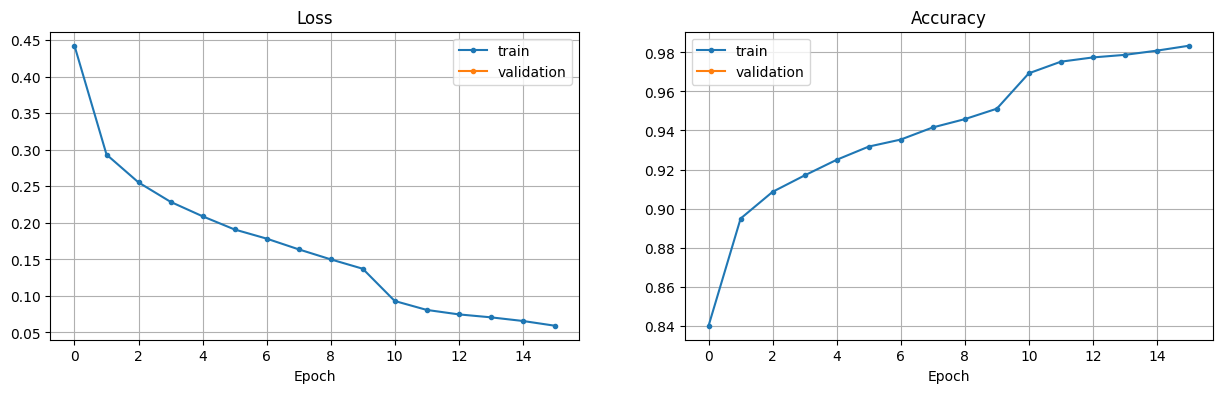

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     [],
                     history.history["accuracy"], [])

In [ ]:
test_loss, test_acc = model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9344 - loss: 0.1877

FINAL TEST ACCURACY: 93.44%
FINAL TEST LOSS:     0.1877


### Save/load the best model

In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("task1_final_full_train.keras")

# --- Load ---
loaded = keras.models.load_model("task1_final_full_train.keras")

              precision    recall  f1-score   support

 T-shirt/top     0.8754    0.8850    0.8802      1000
     Trouser     0.9940    0.9870    0.9905      1000
    Pullover     0.9070    0.8970    0.9020      1000
       Dress     0.9370    0.9370    0.9370      1000
        Coat     0.9006    0.9150    0.9077      1000
      Sandal     0.9879    0.9830    0.9855      1000
       Shirt     0.8098    0.7960    0.8028      1000
     Sneaker     0.9665    0.9820    0.9742      1000
         Bag     0.9861    0.9910    0.9885      1000
  Ankle boot     0.9788    0.9710    0.9749      1000

    accuracy                         0.9344     10000
   macro avg     0.9343    0.9344    0.9343     10000
weighted avg     0.9343    0.9344    0.9343     10000



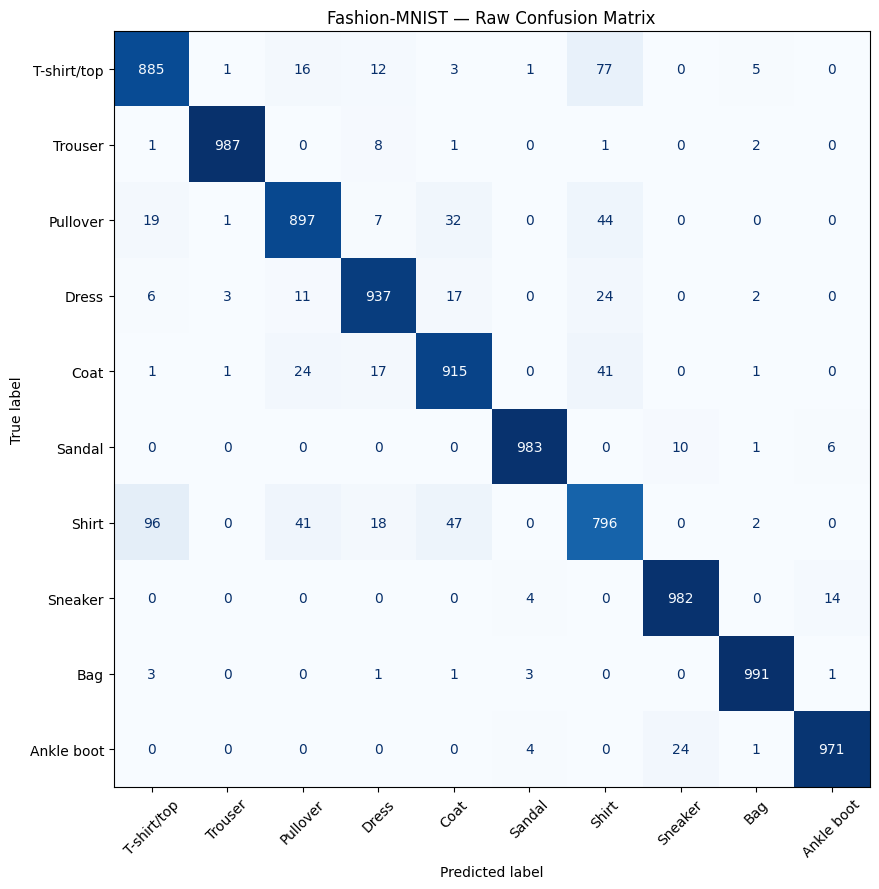

In [ ]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# --- 1. Predictions + true labels out of the DataLoader ---
y_prob = model.predict(test_loader, verbose=0)          # (10000, 10) softmax probabilities
y_pred = y_prob.argmax(axis=1)                          # most probable class indices
y_true = np.concatenate([yb.numpy() for _, yb in test_loader])  # convert each y_batch from tensor to numpy and concatenate into 1D array

# --- 2. Per-class metrics ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 3. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # integer format
    xticks_rotation=45,
)
ax.set_title("Fashion-MNIST — Raw Confusion Matrix")
plt.tight_layout()
plt.show()

### Conclusion

The best model has been established:

- Architecture:
```txt
Input -> normalizer -> cnn_block(64, "relu") -> MaxPooling2D -> cnn_block(2*64, "relu") -> cnn_block(4*64, "relu") -> cnn_block(6*64, "relu") -> GlobalAveragePooling2D -> Dense(10, "softmax")
```

- Params:
```txt
lr = 0.0006
batch_size = 125
optimizer = Adam
loss = sparse_categorical_crossentropy
scheduler = PiecewiseConstantDecay(boundaries=[steps * 10, steps * 15], values=[base_lr, base_lr * 0.1, base_lr * 0.01])
epoch = 16
```

- Scores:
```txt
Final test accuracy = `93.44%`
Final test loss = `0.1877`
```

The results are way better than without the convolutions, as was already stated in the previous home assignment. The model still conflates `shirt` and `t-shirt`, `pullover`, `dress` a lot. I'd say we need larger photos to learn such details.

## Task 2

### The decision

The task is to use transfer learning with **VGG16**. 

The strategy of transfer learning is determined by 2 main factors *together*: (1) **how much data we have per class** (small/medium/large), and (2) **how far our domain is from the data the model was pre-trained on**.

1. First off, **the domain**. And for the current domains, they are very far apart:
	- **Color (severe difference)**. **VGG16** expects colored images, so we must literally copy-paste the grayscale image three times just to match the model's expected input shape.
	- **Resolution/texture.** `ImageNet` is $\approx 500 \times 375$ photographs downsampled to $224 \times 224$, ours is $28 \times 28$ upscaled to $96 \times 96$ (more on why $96$ below). Our images aren't capable to encode enough information (texture, colors etc.) to make the model discern the hardest classes properly: *T-shirt/top*, *Pullover*, *Coat*, *Shirt*. They all share the same upper-body silhouette. What separates them is **texture and fine detail**: sleeve length, collar, buttons, weave. That is precisely the information destroyed by low resolution.
	- **Composition**. `ImageNet` objects sit in scenes — backgrounds, occlusion, varied pose, scale, and lighting. Our `Fashion-MNIST` is a centered, size-normalized, uniformly-lit silhouette on pure black. 

2. The second step is **Data quantity**. For a relative benchmark to compare against we look at `ImageNet`:

| Dataset                | Total Images | Classes | Images per Class |
| :--------------------- | -----------: | ------: | ---------------: |
| `ImageNet` (ILSVRC-2012) |    1,281,167 |   1,000 |            1,281 |
| `Fashion-MNIST` (train)  |       60,000 |      10 |        6,000 |

For our case, the data is very large. `Fashion-MNIST` gives the network 4.7× more examples per class than `ImageNet` itself does.
 
| Images per Class | Band       |
| :--------------- | :--------- |
| < 50             | very small |
| 50 – 500         | small      |
| 500 – 5,000      | medium     |
| > 5,000          | large      |

According to theoretical guidelines below, we ought to drop the transfer-learning strategy:

|                    | Similar domain         | Far domain                  |
| ------------------ | ------------------------------------------------------- | ----------------- |
| **Small data** | Import pre-trained. Freeze the base, train a new head only. The model understands the field already and fine-tuning would overfit.                                                                                | A tough one. Import pre-trained, throw away $n$ last layers (the later the layers, the more domain-specific they are). Add the head, train it. If overfits - throw away more layers, underfit - start unfreezing the topmost remaining base blocks and fine-tune with a very small LR.             |
| **Large data**     | Import pre-trained. Freeze the base, train a new head + dropout. Unfreeze all and fine-tune the whole network with a very small LR. The model understands the field already, and we have enough data to nudge the features. |**- Option 1 - ONLY if the pre-trained architecture suits our input: Import pre-trained. Train only the head + dropout, then fine-tune the whole network with a very small LR.<br>- Option 2. Train from scratch — either our own architecture, or the same architecture with random weights (`weights=None`).** |


Our case is **Large data** + **Far domain** + the architecture doesn't suit our input. Should be the option 2 then: custom architecture or full train with `weights=None`. The custom architecture was implemented in `Task 1`. We did not try adding more custom CNN blocks to prove that the achieved score was the data limit and not architecture-hyperparameters-wise. We could have. The `Task 2` explicitly asks to use the pre-trained version. Although it contradicts the framework, we're going to make an experiment. I think the custom architecture must be at least way more efficient being lightweight and fast in training and inference. VGG16 is huge and honestly a bad one to try for such small images.

### Pre-trained VGG16 - implementation

#### Stage 1 - Feature extraction

What input size to choose?

**VGG16** has 5 pooling layers and passing it a $28 \times 28$ image leads to shrinking into non-existence:  
- $28 \times 28 \rightarrow$ Pool 1 $\rightarrow 14 \times 14$  
- $14 \times 14 \rightarrow$ Pool 2 $\rightarrow 7 \times 7$  
- $7 \times 7 \rightarrow$ Pool 3 $\rightarrow 3.5 \rightarrow 3 \times 3$  
- $3 \times 3 \rightarrow$ Pool 4 $\rightarrow 1.5 \rightarrow 1 \times 1$  
- $1 \times 1 \rightarrow$ Pool 5 $\rightarrow 0 \times 0$  

The MNIST-Fashion is also grayscale. We have to use `keras.layers.Resizing` to artificially stretch our tiny $28 \times 28$ image up to $96 \times 96$ before feeding it to **VGG16**. We need **at least** $96 \times 96$ because $96$ is large enough to survive being cut in half 5 times ($96 \rightarrow 48 \rightarrow 24 \rightarrow 12 \rightarrow 6 \rightarrow 3$). 

> At the same time, passing something like $32 \times 32$ survives all five pools as well ($32 \to 16 \to 8 \to 4 \to 2 \to 1$), however then, the last few matrices become $2 \times 2$ (4 elements) and $1 \times 1$ (1 element). A $3 \times 3$ convolutional filter on a $2 \times 2$ map is mostly multiplying against the zero-padding rather than the image, so those layers emit near-noise. At $96 \times 96$ the last block still works on a $6 \times 6$ map ($96 \to 48 \to 24 \to 12 \to 6 \to 3$), so every filter sees real content and GAP has $3 \times 3=9$ positions to average instead of $1$. It is *important* to note that it is $9$ **positions**, not elements. Because for each final $3 \times 3$ there are $512$ convolutional filters in the architecture - `keras.layers.Conv2D(filters=512, kernel_size=(3,3))`.

In [ ]:
IMG_SIZE = 96                               # the closest size to reshape the input to to keep up with the architecture AND extract meaningful data

base = keras.applications.VGG16(
    weights="imagenet",                     # use pre-trained model according to the task
    include_top=False,                      # remove the head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
)
base.trainable = False                      # freeze the whole base

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

$14,714,688$ params even without the head. Almost 12 times bigger than the custom model.

To accelerate the training and solve the encountered out-of-memory (OOM) issues:
1. Compose the image preprocessor (extractor) that:
    - reshapes the data properly for the expected VGG16's input
    - runs the forward pass through the freezed base (all 14M params)
2. Input and process the images via extractor in batches.

In [ ]:
# --- build the frozen extractor and run the data through it a single time ---
extractor = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),                                       # current inputs are 28x28 first
    keras.layers.Reshape((28, 28, 1)),                                        # explicitly add the channel dimension (28,28) -> (28,28,1)
    keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1)),           # repeat gray 3 times to resemble the 3 channel-format (RGB)
    keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear"),      # resize into the expected minimum of 96x96
    keras.layers.Lambda(keras.applications.vgg16.preprocess_input),           # match VGG's scaling expectations
    base,                                                                     # frozen base
    keras.layers.GlobalAveragePooling2D(),                                    # flatten using GAP as in our custom architecture -> (512,)
])

def extract(loader):
    feats, labels = [], []
    for xb, yb in loader:
        feats.append(extractor.predict(xb, verbose=0))      # predict already enforces inference mode
        labels.append(np.asarray(yb))
    return np.concatenate(feats), np.concatenate(labels)

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=1024, shuffle=True, generator=torch_gen)

# compose new training and validation data by (1) reshaping the images and (2) running the forward pass through the freezed base
Xtr, ytr = extract(train_loader)
Xva, yva = extract(valid_loader)

Now, the tuner only sees a small dense head. Adding a regularization layer is the industry standard for large data.

In [ ]:
def build_head(hp):
       keras.utils.set_random_seed(RANDOM_SEED)                       # same init for every trial
       torch_gen.manual_seed(RANDOM_SEED)                             # same shuffle order for every trial

       inputs = keras.Input(shape=(512,))                             # the output of the last layer in the extractor is 512
       d  = hp.Float("dropout", 0.0, 0.3, step=0.1)                   # tune dropout - 4 options (0.0, 0.1, 0.2, 0.3)
       lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")                # tune lr
       name = hp.Choice("optimizer", ["adam", "sgd", "rmsprop"])      # tune optimizer - 3 options (adam, sgd, rmsprop)
       opt = {"adam": keras.optimizers.Adam(lr),
              "sgd": keras.optimizers.SGD(lr, momentum=0.9),
              "rmsprop": keras.optimizers.RMSprop(lr)}[name]

       x = keras.layers.Dropout(d, seed=RANDOM_SEED)(inputs)
       outputs = keras.layers.Dense(10, activation="softmax")(x)
       model = keras.Model(inputs, outputs)
       model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
       return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,                    # init new search at /fashion_mnist/task_2_tuning/
)

tuner.search(
    # data that has already passed the extractor: (Xtr, ytr, Xva, yva)
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 31s]
val_accuracy: 0.8708333373069763

Best val_accuracy So Far: 0.8765000104904175
Total elapsed time: 00h 33m 46s
{'dropout': 0.2, 'lr': 0.00019528654576328537, 'optimizer': 'adam'}


In [18]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
12,12,0.876500,0.2,0.000195,adam
10,10,0.874833,0.0,0.000363,rmsprop
4,04,0.872667,0.2,0.000152,rmsprop
11,11,0.872500,0.1,0.000551,rmsprop
14,14,0.870833,0.2,0.000251,rmsprop
8,08,0.870500,0.0,0.000141,rmsprop
0,00,0.867500,0.1,0.000119,sgd
2,02,0.867000,0.1,0.000136,sgd
6,06,0.865167,0.0,0.000975,rmsprop
7,07,0.865000,0.1,0.000896,sgd


The search looks flat (no variation in scores based on the hyperparameter setup). 
- `SGD` is definitely off the table.

Trying again to confirm.

In [ ]:
def build_head(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    inputs = keras.Input(shape=(512,))
    d  = hp.Float("dropout", 0.0, 0.3, step=0.1)
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    name = hp.Choice("optimizer", ["adam", "rmsprop"])
    opt = {"adam": keras.optimizers.Adam(lr),
           "rmsprop": keras.optimizers.RMSprop(lr)}[name]

    x = keras.layers.Dropout(d, seed=RANDOM_SEED)(inputs)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15+15,                   # another 15
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                    # continue the search at /fashion_mnist/task_2_tuning/
)

tuner.search(
    # data that has already passed the extractor: (Xtr, ytr, Xva, yva)
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 30 Complete [00h 02m 09s]
val_accuracy: 0.8650000095367432

Best val_accuracy So Far: 0.8765000104904175
Total elapsed time: 01h 09m 21s
{'dropout': 0.2, 'lr': 0.00019528654576328537, 'optimizer': 'adam'}


In [23]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
6,12,0.876500,0.2,0.000195,adam
15,15,0.875167,0.0,0.000624,adam
7,10,0.874833,0.0,0.000363,rmsprop
22,22,0.873833,0.0,0.000362,rmsprop
28,28,0.873500,0.1,0.000123,rmsprop
11,04,0.872667,0.2,0.000152,rmsprop
0,11,0.872500,0.1,0.000551,rmsprop
3,14,0.870833,0.2,0.000251,rmsprop
2,08,0.870500,0.0,0.000141,rmsprop
23,23,0.869667,0.2,0.000917,adam


The tendency has retained. The final check to make sure:
- fixed the `dropout=0.2` and `optim=Adam`
- increase LR range $[1e-4, 1e-2] \to [1e-3, 1e-2]$

In [ ]:
def build_head(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    inputs = keras.Input(shape=(512,))
    lr = hp.Float("lr", 1e-3, 1e-2, sampling="log")

    x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(inputs)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15+15+15,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                    # continue
)

tuner.search(
    # data that has already passed the extractor: (Xtr, ytr, Xva, yva)
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 45 Complete [00h 01m 52s]
val_accuracy: 0.8684999942779541

Best val_accuracy So Far: 0.8778333067893982
Total elapsed time: 01h 53m 40s
{'dropout': 0.2, 'lr': 0.0003243806953412315, 'optimizer': 'rmsprop'}


In [27]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
42,42,0.877833,0.2,0.000324,rmsprop
39,39,0.877500,0.1,0.000176,sgd
41,41,0.877167,0.0,0.000228,adam
37,37,0.877000,0.2,0.000255,sgd
17,12,0.876500,0.2,0.000195,adam
16,15,0.875167,0.0,0.000624,adam
19,10,0.874833,0.0,0.000363,rmsprop
7,22,0.873833,0.0,0.000362,rmsprop
43,43,0.873667,0.2,0.000507,adam
35,35,0.873500,0.1,0.000641,adam


The search has proved to show almost no improvement with the hyperparameter change. 

The final tuning to find the best learning rate around the highest-scored `0.000324`:

In [ ]:
def build_head(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    inputs = keras.Input(shape=(512,))
    lr = hp.Float("lr", min_value=0.0003, max_value=0.0007, step=0.00005) # discrete lr - 9 iterations (0.0007-0.0003)/0.00005 and 0.0003

    x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(inputs)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

tuner = kt.RandomSearch(
    build_head,
    objective="val_accuracy",
    max_trials=15+15+15+9,
    directory="task_2_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                    # continue
)

tuner.search(
    # data that has already passed the extractor: (Xtr, ytr, Xva, yva)
    x=Xtr,
    y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 54 Complete [00h 01m 54s]
val_accuracy: 0.8479999899864197

Best val_accuracy So Far: 0.8778333067893982
Total elapsed time: 02h 28m 43s
{'dropout': 0.2, 'lr': 0.0003243806953412315, 'optimizer': 'rmsprop'}


In [31]:
debug_tuner(tuner)

,trial_id,score,dropout,lr,optimizer
22,42,0.877833,0.2,0.000324,rmsprop
12,39,0.877500,0.1,0.000176,sgd
27,41,0.877167,0.0,0.000228,adam
21,37,0.877000,0.2,0.000255,sgd
29,12,0.876500,0.2,0.000195,adam
47,47,0.876333,0.0,0.000356,rmsprop
49,49,0.876333,0.1,0.000141,rmsprop
28,15,0.875167,0.0,0.000624,adam
31,10,0.874833,0.0,0.000363,rmsprop
48,48,0.874000,0.1,0.000504,rmsprop


Training the head separately with best params so far:

In [ ]:
# --- train the winning head and keep its weights for the fine-tuning stage ---
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

best_head = keras.Sequential([
    keras.Input(shape=(512,)),
    keras.layers.Dropout(0.2, seed=RANDOM_SEED),
    keras.layers.Dense(10, activation="softmax"),
])
best_head.compile(
    optimizer=keras.optimizers.Adam(0.000324),  # best tuned lr
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
best_head.fit(
    x=Xtr, y=ytr,
    validation_data=(Xva, yva),
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                             restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

head_weights = best_head.layers[-1].get_weights()
print("saved head weights:", [w.shape for w in head_weights])

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6808 - loss: 1.8370 - val_accuracy: 0.8318 - val_loss: 0.6132
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8221 - loss: 0.6150 - val_accuracy: 0.8523 - val_loss: 0.4543
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8476 - loss: 0.4626 - val_accuracy: 0.8663 - val_loss: 0.4029
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8571 - loss: 0.4190 - val_accuracy: 0.8692 - val_loss: 0.3818
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8606 - loss: 0.3984 - val_accuracy: 0.8743 - val_loss: 0.3730
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8643 - loss: 0.3899 - val_accuracy: 0.8735 - val_loss: 0.3724
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8656 - loss: 0.3826 - val_accuracy: 0.8738 - val_loss: 0.3693
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8664 - loss:

##### Conclusion

After $54$ trials over dropout, learning rate, and optimizer, the frozen-VGG16 model saturates at $\mathbf{87.78\%}$ validation accuracy, while the purpose-built CNN from Task 1 reached $\mathbf{93.44\%}$ on test. The gap is significant. 

Also, the search appears to have become flat, reporting a ceiling. The results show no structure no matter the grouping, every configuration converges to the same number. Hyperparameters are not the bottleneck.

The same scores for different dropout values confirm that we are not dealing with **overfitting**. We are only tuning the small head part, it would be hard to overfit. The current head has $512 \times 10 + 10 = \mathbf{5{,}130}$ parameters against $54{,}000$ training samples - very few. Therefore, the model is **underfitting** the task. With the current data, we can claim that at the moment, the 10 Fashion-MNIST classes inside VGG16's frozen feature space are linearly separable at about $87.8\%$ (called a **linear probe** - the standard way to measure the quality of a frozen representation).

This confirms our initial observation. Given that the head is just a simple final classifier, we infer that underfitting happens because the head is being handed a representation that doesn't contain what it needs (the domain is different). As befits large data whose domain is also different from the pre-trained backbone, we need to gradually start unfreezing the base layers to alter extracted features for them to be closer to the task, as we would do for small data.

### Fine-tuning

Based on the specified guidelines above, we are supposed to train the **whole** network now with a very small `lr`. However, the model is too huge and we are only sticking to this because of the task. I don't have the resources to tune the whole thing. I am only going to unfreeze the last block.

For our specific case, **VGG16** is built in "blocks". If we look at the source code of **VGG16**:
- **Block 1:** (2 Convs + 1 Pool = 3 layers)
- **Block 2:** (2 Convs + 1 Pool = 3 layers)
- **Block 3:** (3 Convs + 1 Pool = 4 layers)
- **Block 4:** (3 Convs + 1 Pool = 4 layers)
- **Block 5:** (3 Convs + 1 Pool = 4 layers)

(Total = 19 layers inside `base.layers`, including the `InputLayer`)
 
Based on the decision-making table above, we want to unfreeze gradually, which the topmost block - only the **block 5** - $4$ **layers**.

In [ ]:
def build_model(base):
  # 1. Freeze all but the top 4 layers of the base (Block 5)
  base.trainable = True
  for layer in base.layers[:-4]:
      layer.trainable = False

  # 2. Build the FULL end-to-end model:
  inputs = keras.Input(shape=(28, 28))

  # Preprocessing (identical to the extractor)
  x = keras.layers.Reshape((28, 28, 1))(inputs)
  x = keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1))(x)
  x = keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
  x = keras.layers.Lambda(keras.applications.vgg16.preprocess_input)(x)

  # Pass through the partially trainable base
  x = base(x)
  x = keras.layers.GlobalAveragePooling2D()(x)

  # Add the tuned head
  x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(x)
  head = keras.layers.Dense(10, activation="softmax")
  outputs = head(x)                      # builds it, so that set_weights becomes legal

  model = keras.Model(inputs, outputs)
  head.set_weights(head_weights)         # start from the TRAINED head
  return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

keras.backend.clear_session()   # reset Keras-internal state (to train from scratch) and free RAM/VRAM
gc.collect()                    # clear RAM
torch.cuda.empty_cache()        # clear VRAM (the GPU memory)

# Re-instantiate a FRESH base model from ImageNet weights
fresh_base = keras.applications.VGG16(
    weights="imagenet",                     # use pre-trained model
    include_top=False,                      # remove the head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),    # expect the output as specified
)
fresh_base.trainable = False                # freeze the base


# Smaller batch size is needed here; backpropagating through VGG Block 5 uses much more VRAM, it crashes
train_loader, valid_loader = build_loaders(batch_size=16, shuffle=True, generator=torch_gen)

model = build_model(fresh_base)

# Compile the end-to-end model
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),     # Microscopic LR to prevent wrecking the pretrained weights
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 171s 51ms/step - accuracy: 0.8927 - loss: 0.3029 - val_accuracy: 0.9115 - val_loss: 0.2425
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 178s 53ms/step - accuracy: 0.9241 - loss: 0.2094 - val_accuracy: 0.9232 - val_loss: 0.2139
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 171s 51ms/step - accuracy: 0.9415 - loss: 0.1602 - val_accuracy: 0.9272 - val_loss: 0.2085
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 172s 51ms/step - accuracy: 0.9543 - loss: 0.1247 - val_accuracy: 0.9287 - val_loss: 0.2005
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 172s 51ms/step - accuracy: 0.9635 - loss: 0.0992 - val_accuracy: 0.9323 - val_loss: 0.2032
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 171s 51ms/step - accuracy: 0.9720 - loss: 0.0790 - val_accuracy: 0.9353 - val_loss: 0.2224
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 170s 50ms/step - accuracy: 0.9766 - loss: 0.0640 - val_accuracy: 0.9307 - val_loss: 0.2260
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 170s 51ms/step - accuracy: 

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.3029  val_loss=0.2425  train_acc=0.8927  val_acc=0.9115
Epoch  1: train_loss=0.2094  val_loss=0.2139  train_acc=0.9241  val_acc=0.9232
Epoch  2: train_loss=0.1602  val_loss=0.2085  train_acc=0.9415  val_acc=0.9272
Epoch  3: train_loss=0.1247  val_loss=0.2005  train_acc=0.9543  val_acc=0.9287
Epoch  4: train_loss=0.0992  val_loss=0.2032  train_acc=0.9635  val_acc=0.9323
Epoch  5: train_loss=0.0790  val_loss=0.2224  train_acc=0.9720  val_acc=0.9353
Epoch  6: train_loss=0.0640  val_loss=0.2260  train_acc=0.9766  val_acc=0.9307
Epoch  7: train_loss=0.0517  val_loss=0.2229  train_acc=0.9819  val_acc=0.9378
Epoch  8: train_loss=0.0417  val_loss=0.2340  train_acc=0.9853  val_acc=0.9340



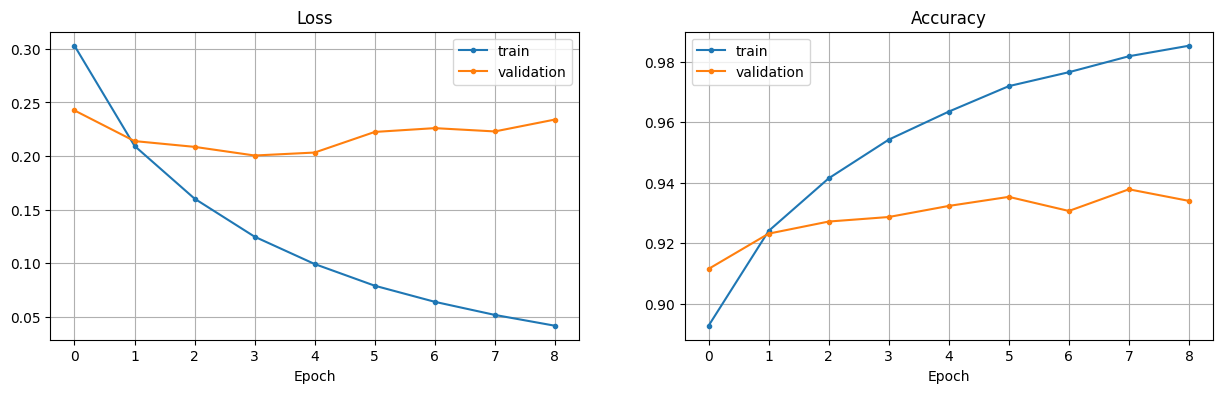

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Best so far: `Epoch [3]: train_loss=0.1247  val_loss=0.2005  train_acc=0.9543  val_acc=0.9287`

#### Learning rate schedulers

In [ ]:
def build_rand_search_model(hp, epochs):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    name = hp.Choice("scheduler", [
            "constant",          # baseline: flat 1e-5, for comparison
            "custom_stairs",     # custom staircase
            "exponential",       # smooth *0.9 per epoch
            "cosine",            # glide 0.0006 -> ~0 over the whole run
            "cosine_restarts",   # cosine, but periodically jumps back up (escapes basins)
            "inverse_time",      # 1/(1+decay*t)
            "piecewise",         # gentler staircase: /10 at epoch 4, /100 at 5
        ])

    base  = 1e-5
    steps = len(train_loader)          # batches per epoch
    S     = keras.optimizers.schedules

    if name == "custom_stairs":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 4, steps * 6, steps * 8],
                                      values=[base, 1e-6, 1e-7, 1e-8])
    elif name == "exponential":
        lr = S.ExponentialDecay(base, decay_steps=steps, decay_rate=0.9)
    elif name == "cosine":
        lr = S.CosineDecay(base, decay_steps=steps * epochs)
    elif name == "cosine_restarts":
        lr = S.CosineDecayRestarts(base, first_decay_steps=steps * 3)
    elif name == "inverse_time":
        lr = S.InverseTimeDecay(base, decay_steps=steps, decay_rate=0.5)
    elif name == "piecewise":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 4, steps * 5],
                                      values=[base, base * 0.1, base * 0.01])
    else: # "constant"
        lr = base

    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)
    keras.backend.clear_session()
    gc.collect()
    torch.cuda.empty_cache()

    # Re-instantiate a FRESH base model from ImageNet weights
    fresh_base = keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    fresh_base.trainable = False

    for layer in fresh_base.layers[:-4]:
        layer.trainable = False

    # Build the FULL end-to-end model
    inputs = keras.Input(shape=(28, 28))

    # Preprocessing (identical to the extractor)
    x = keras.layers.Reshape((28, 28, 1))(inputs)
    x = keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1))(x)
    x = keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
    x = keras.layers.Lambda(keras.applications.vgg16.preprocess_input)(x)

    # Pass through the partially trainable base
    x = fresh_base(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    # Add the tuned head
    x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(x)
    head = keras.layers.Dense(10, activation="softmax")
    outputs = head(x)

    model = keras.Model(inputs, outputs)
    head.set_weights(head_weights)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=16, shuffle=True, generator=torch_gen)

sched_tuner = kt.GridSearch(
    functools.partial(build_rand_search_model, epochs=30),
    objective="val_accuracy",
    directory="task_2_fine_tuning_lr_schedulers",
    project_name="fashion_mnist_schedulers",
    seed=RANDOM_SEED,
    overwrite=True, # start a new search
)
sched_tuner.search(x=train_loader, validation_data=valid_loader, epochs=30,
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                            restore_best_weights=True, verbose=1)],
                   verbose=1, shuffle=False)

Trial 7 Complete [00h 28m 10s]
val_accuracy: 0.9380000233650208

Best val_accuracy So Far: 0.9380000233650208
Total elapsed time: 03h 27m 08s


In [ ]:
debug_tuner(sched_tuner)

,trial_id,score,scheduler
0,0000,0.938000,constant
6,0006,0.938000,piecewise
3,0003,0.937167,cosine
2,0002,0.936167,exponential
1,0001,0.935333,custom_stairs
4,0004,0.935333,cosine_restarts
5,0005,0.933167,inverse_time


The new best: `0.938000`. Fitting and visualizing the best model:

In [ ]:
def build_model(base):
  base.trainable = True
  for layer in base.layers[:-4]:
      layer.trainable = False

  # Build the FULL end-to-end model
  inputs = keras.Input(shape=(28, 28))

  # Preprocessing (identical to the extractor)
  x = keras.layers.Reshape((28, 28, 1))(inputs)
  x = keras.layers.Lambda(lambda t: keras.ops.repeat(t, 3, axis=-1))(x)
  x = keras.layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
  x = keras.layers.Lambda(keras.applications.vgg16.preprocess_input)(x)

  # Pass through the partially trainable base
  x = base(x)
  x = keras.layers.GlobalAveragePooling2D()(x)

    # Add the tuned head
  x = keras.layers.Dropout(0.2, seed=RANDOM_SEED)(x)
  head = keras.layers.Dense(10, activation="softmax")
  outputs = head(x)

  model = keras.Model(inputs, outputs)
  head.set_weights(head_weights)
  return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# Re-instantiate a FRESH base model from ImageNet weights
fresh_base = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
fresh_base.trainable = False


train_loader, valid_loader = build_loaders(batch_size=16, shuffle=True, generator=torch_gen)
model = build_model(fresh_base)

# Compile the end-to-end model
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 167s 49ms/step - accuracy: 0.8408 - loss: 0.5164 - val_accuracy: 0.9077 - val_loss: 0.2613
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9170 - loss: 0.2348 - val_accuracy: 0.9232 - val_loss: 0.2204
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9366 - loss: 0.1773 - val_accuracy: 0.9258 - val_loss: 0.2144
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 167s 49ms/step - accuracy: 0.9491 - loss: 0.1414 - val_accuracy: 0.9258 - val_loss: 0.2097
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9590 - loss: 0.1116 - val_accuracy: 0.9380 - val_loss: 0.1949
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 165s 49ms/step - accuracy: 0.9689 - loss: 0.0875 - val_accuracy: 0.9312 - val_loss: 0.2153
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 0.9740 - loss: 0.0723 - val_accuracy: 0.9328 - val_loss: 0.2324
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 166s 49ms/step - accuracy: 

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.5164  val_loss=0.2613  train_acc=0.8408  val_acc=0.9077
Epoch  1: train_loss=0.2348  val_loss=0.2204  train_acc=0.9170  val_acc=0.9232
Epoch  2: train_loss=0.1773  val_loss=0.2144  train_acc=0.9366  val_acc=0.9258
Epoch  3: train_loss=0.1414  val_loss=0.2097  train_acc=0.9491  val_acc=0.9258
Epoch  4: train_loss=0.1116  val_loss=0.1949  train_acc=0.9590  val_acc=0.9380
Epoch  5: train_loss=0.0875  val_loss=0.2153  train_acc=0.9689  val_acc=0.9312
Epoch  6: train_loss=0.0723  val_loss=0.2324  train_acc=0.9740  val_acc=0.9328
Epoch  7: train_loss=0.0580  val_loss=0.2194  train_acc=0.9789  val_acc=0.9363
Epoch  8: train_loss=0.0474  val_loss=0.2224  train_acc=0.9835  val_acc=0.9348
Epoch  9: train_loss=0.0389  val_loss=0.2091  train_acc=0.9868  val_acc=0.9360



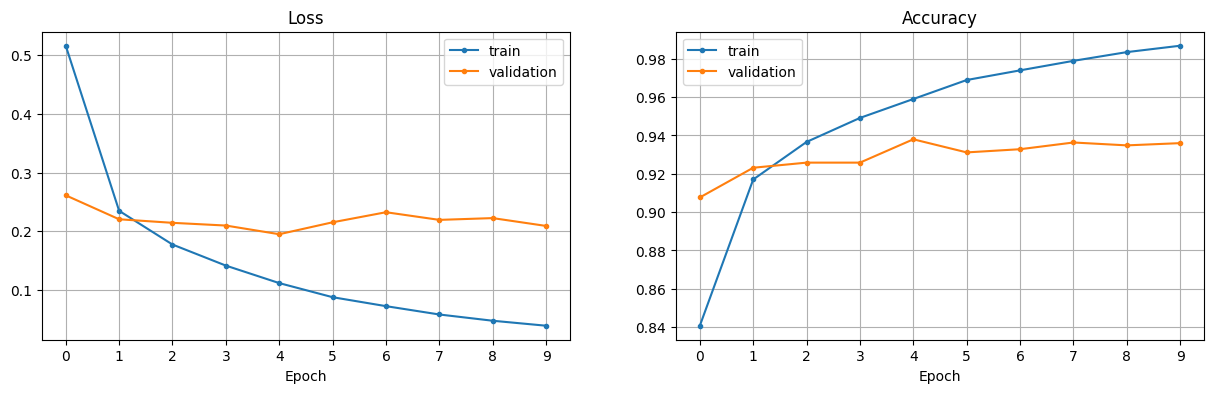

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

The best confirmed: `Epoch  4: train_loss=0.1116  val_loss=0.1949  train_acc=0.9590  val_acc=0.9380`

### Best final model and evaluation

Fit on full train before assessing on test:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# Re-instantiate a FRESH base model from ImageNet weights
fresh_base = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
fresh_base.trainable = False


full_train_loader = DataLoader(full_train_ds, batch_size=16, shuffle=True, generator=torch_gen)
steps = len(full_train_loader)          # batches per epoch (for lr scheduler)
model = build_model(fresh_base)

# Compile the end-to-end model
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x=full_train_loader,
    epochs=5,
    verbose=1,
    shuffle=False,
)

Epoch 1/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 172s 46ms/step - accuracy: 0.8458 - loss: 0.5003
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 46ms/step - accuracy: 0.9179 - loss: 0.2283
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 46ms/step - accuracy: 0.9368 - loss: 0.1753
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 45ms/step - accuracy: 0.9493 - loss: 0.1391
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 171s 46ms/step - accuracy: 0.9597 - loss: 0.1103


Smoothed scores over epochs grouped by folds:



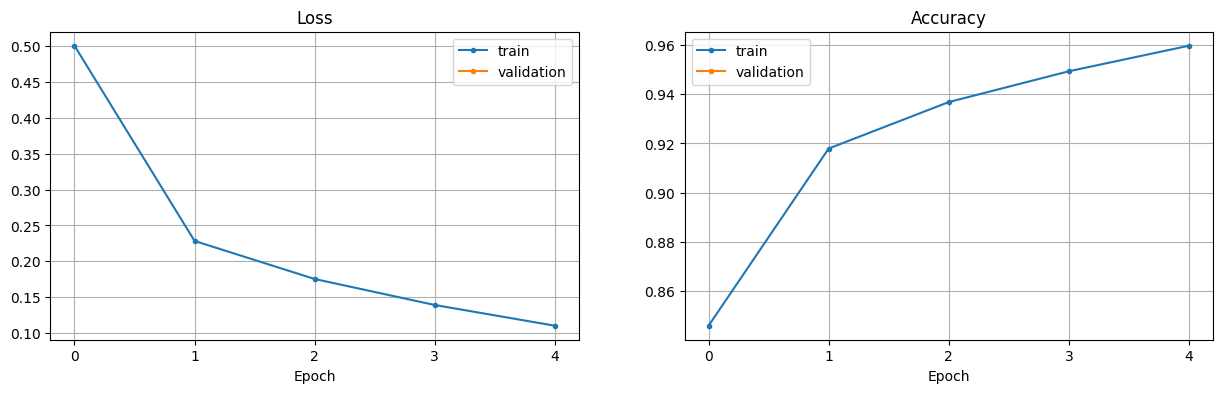

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     [],
                     history.history["accuracy"], [])

In [ ]:
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
test_loss, test_acc = model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9335 - loss: 0.1942

FINAL TEST ACCURACY: 93.35%
FINAL TEST LOSS:     0.1942


In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("task2_final_full_train.keras")

# --- Load ---
loaded = keras.models.load_model(
    "task2_final_full_train.keras",
    safe_mode=False,                # to permit deserializing Lambda layers
)

              precision    recall  f1-score   support

 T-shirt/top     0.8677    0.9120    0.8893      1000
     Trouser     0.9980    0.9860    0.9920      1000
    Pullover     0.8851    0.9170    0.9008      1000
       Dress     0.9140    0.9460    0.9297      1000
        Coat     0.9255    0.8700    0.8969      1000
      Sandal     0.9929    0.9780    0.9854      1000
       Shirt     0.8197    0.7730    0.7957      1000
     Sneaker     0.9628    0.9840    0.9733      1000
         Bag     0.9901    0.9970    0.9935      1000
  Ankle boot     0.9789    0.9720    0.9754      1000

    accuracy                         0.9335     10000
   macro avg     0.9335    0.9335    0.9332     10000
weighted avg     0.9335    0.9335    0.9332     10000



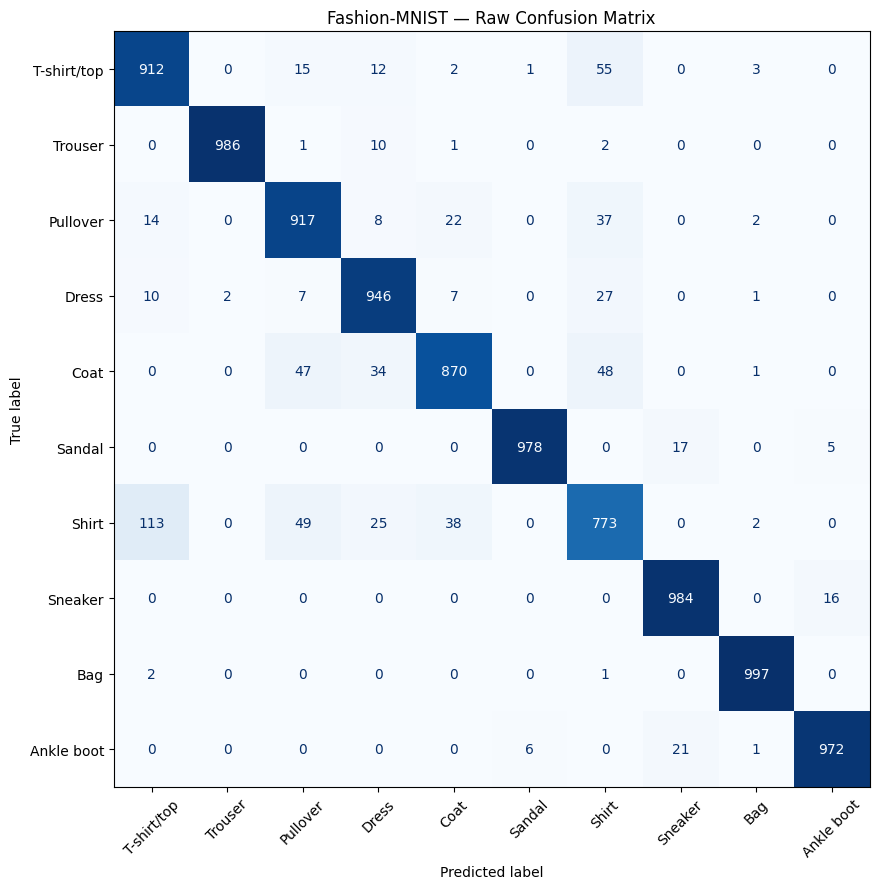

In [ ]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# --- 1. Predictions + true labels out of the DataLoader ---
y_prob = model.predict(test_loader, verbose=0)          # (10000, 10) softmax probabilities
y_pred = y_prob.argmax(axis=1)                          # most probable class indices
y_true = np.concatenate([yb.numpy() for _, yb in test_loader])  # convert each y_batch from tensor to numpy and concatenate into 1D array

# --- 2. Per-class metrics ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 3. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # integer format
    xticks_rotation=45,
)
ax.set_title("Fashion-MNIST — Raw Confusion Matrix")
plt.tight_layout()
plt.show()

### Conclusion

The conclusion is no different from the previous. The most complex classes are still confused, the custom model turned out slightly better in terms of both accuracy and loss.

Task 1 test metrics:
- Accuracy: 93.44%
- Loss: 0.1877

Task 2 test metrics:
- Accuracy: 93.35%
- Loss: 0.1942

As discussed, the model is suboptimal because it is 12 times heavier, more pain to train and infer AND it doesn't surpass the custom one. In fact, even if it did, the trade-off question would still be raised. The data is most likely the culprit why we are this ceiling.

## Task 3. Trained from scratch (my own experiment to challenge the task). 

This is what the decision was supposed to be based on the contemplation in the Task 2 - to train the architecture from scratch. However, as shown above, `VGG16` is a really bad option here. `MobileNetV2` is really similar in parameters to ours in Task 1:
- Task 1: $1,261,133$ params
- Task 3: $2,270,794$ params (x1.8 times bigger)

Therefore, it is a perfect candidate to check if more parameters wins the score. If no, this is the final evidence we needed to state the data is the ceiling.

In [ ]:
fresh_mobilenet = keras.applications.MobileNetV2(
    weights=None,
    include_top=True,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    classes=10,
)
fresh_mobilenet.summary()

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

`MobileNetV2`, having been trained on `ImageNet` as well, has exactly the same requirements as before. The input style and reasoning don't change. Both models shrink an image by 32 times.

In [ ]:
IMG_SIZE = 96

# --- one-time input prep: (N, 28, 28) -> (N, 96, 96, 1) float32 ---
def prepare_inputs(X, img_size=IMG_SIZE, chunk=2000):
    out = []
    for i in range(0, len(X), chunk):
        x = keras.ops.convert_to_tensor(X[i : i + chunk], dtype="float32")
        x = keras.ops.reshape(x, (-1, 28, 28, 1))
        x = keras.ops.image.resize(x, (img_size, img_size), interpolation="bilinear")
        out.append(keras.ops.convert_to_numpy(x))
    return np.concatenate(out, axis=0)

In [ ]:
class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray, img_size: int | None = None):
        if img_size is not None:                       # one-time resize (N,28,28) -> (N,H,W,1)
            data = prepare_inputs(data, img_size)
        self.data = torch.from_numpy(data).clone().float()
        self.targets = torch.from_numpy(targets).clone().int()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

full_train_ds_96 = FashionMNISTDataset(X_train_writable, y_train_writable, img_size=IMG_SIZE)
test_ds_96 = FashionMNISTDataset(X_test_writable,  y_test_writable,  img_size=IMG_SIZE)

# same split as Tasks 1 and 2
tr_ds = Subset(full_train_ds_96, train_ds.indices)
va_ds = Subset(full_train_ds_96, valid_ds.indices)

In [ ]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # no need to reshape here, it was done in advance in tr_ds / va_ds
    net = keras.applications.MobileNetV2(
        weights=None,
        include_top=True,
        input_shape=(IMG_SIZE, IMG_SIZE, 1),
        classes=10,
    )

    # because the model was trained on ImageNet, BatchNorms' momentums are too high and would take too many epochs
    for layer in net.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.momentum = 0.9               # decrease to converge faster

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = normalizer(inputs)
    outputs = net(x)
    model = keras.Model(inputs, outputs)

    # Define the hyperparameters
    # 4 specific options for lr to understand around what scale it performs best
    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# train_loader / valid_loader come from the prep block above (tr_ds / va_ds)
train_loader = DataLoader(tr_ds, batch_size=125, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(va_ds, batch_size=125, shuffle=False)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="task_3_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /fashion_mnist/task_3_tuning/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 1 Complete [00h 21m 15s]
val_accuracy: 0.9143333435058594

Best val_accuracy So Far: 0.9143333435058594
Total elapsed time: 00h 21m 15s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
0.0005            |0.001             |lr
adam              |adam              |optimizer

Epoch 1/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 139s 321ms/step - accuracy: 0.7754 - loss: 0.6016 - val_accuracy: 0.8553 - val_loss: 0.3941
Epoch 2/10
143/432 ━━━━━━━━━━━━━━━━━━━━ 1:25 296ms/step - accuracy: 0.8708 - loss: 0.3465

KeyboardInterrupt: 

In [ ]:
debug_tuner(tuner)

,trial_id,score,lr,optimizer
0,00,0.914333,0.0010,adam
1,01,NaN,0.0005,adam


It happened so that the searched picked up a high LR from the specified. I am able to tell from the epochs and how gradually it converges that a lower LR will only slow it down more, so we're keeping `lr=0.001` and experimenting with `0.005` right away for all 3 optimizers:

In [ ]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    net = keras.applications.MobileNetV2(
        weights=None,
        include_top=True,
        input_shape=(IMG_SIZE, IMG_SIZE, 1),
        classes=10,
    )

    for layer in net.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.momentum = 0.9

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = normalizer(inputs)
    outputs = net(x)
    model = keras.Model(inputs, outputs)

    # Define the hyperparameters
    lr = hp.Choice("lr", values=[0.005]) # fixed
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

# train_loader / valid_loader come from the prep block above (tr_ds / va_ds)
train_loader = DataLoader(tr_ds, batch_size=125, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(va_ds, batch_size=125, shuffle=False)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15+3,
    directory="task_3_tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=False,                             # continue
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 9 Complete [00h 21m 42s]
val_accuracy: 0.9193333387374878

Best val_accuracy So Far: 0.9213333129882812
Total elapsed time: 03h 18m 13s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
0.0001            |0.001             |lr
rmsprop           |rmsprop           |optimizer

Epoch 1/10
 81/432 ━━━━━━━━━━━━━━━━━━━━ 1:39 283ms/step - accuracy: 0.2284 - loss: 2.8841

KeyboardInterrupt: 

In [ ]:
debug_tuner(tuner)

,trial_id,score,lr,optimizer
6,06,0.921333,0.0010,rmsprop
1,01,0.921167,0.0005,adam
7,07,0.920833,0.0005,rmsprop
2,02,0.920167,0.0050,sgd
8,08,0.919333,0.0001,sgd
3,03,0.918833,0.0050,adam
5,05,0.916500,0.0001,adam
0,00,0.914333,0.0010,adam
4,04,0.911167,0.0005,sgd
9,09,NaN,0.0001,rmsprop


`lr=0.001` has proved to be superior with `optim=rmsprop` after all. Visualizing the best model:

In [ ]:
def build_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    net = keras.applications.MobileNetV2(
        weights=None,
        include_top=True,
        input_shape=(IMG_SIZE, IMG_SIZE, 1),
        classes=10,
    )

    for layer in net.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.momentum = 0.9

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = normalizer(inputs)
    outputs = net(x)
    model = keras.Model(inputs, outputs)

    optimizer_obj = keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

# train_loader / valid_loader come from the prep block above (tr_ds / va_ds)
train_loader = DataLoader(tr_ds, batch_size=125, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(va_ds, batch_size=125, shuffle=False)
tuned_model = build_model()

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 143s 330ms/step - accuracy: 0.7981 - loss: 0.5616 - val_accuracy: 0.8632 - val_loss: 0.3734
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 133s 309ms/step - accuracy: 0.8905 - loss: 0.2977 - val_accuracy: 0.8928 - val_loss: 0.2870
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 131s 302ms/step - accuracy: 0.9099 - loss: 0.2455 - val_accuracy: 0.9012 - val_loss: 0.2797
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 131s 303ms/step - accuracy: 0.9219 - loss: 0.2134 - val_accuracy: 0.9062 - val_loss: 0.2515
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 132s 305ms/step - accuracy: 0.9304 - loss: 0.1894 - val_accuracy: 0.9210 - val_loss: 0.2174
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 130s 302ms/step - accuracy: 0.9366 - loss: 0.1719 - val_accuracy: 0.9203 - val_loss: 0.2261
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 131s 303ms/step - accuracy: 0.9430 - loss: 0.1554 - val_accuracy: 0.9117 - val_loss: 0.2349
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 130s 302ms/step - accuracy: 0.9493 -

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.5616  val_loss=0.3734  train_acc=0.7981  val_acc=0.8632
Epoch  1: train_loss=0.2977  val_loss=0.2870  train_acc=0.8905  val_acc=0.8928
Epoch  2: train_loss=0.2455  val_loss=0.2797  train_acc=0.9099  val_acc=0.9012
Epoch  3: train_loss=0.2134  val_loss=0.2515  train_acc=0.9219  val_acc=0.9062
Epoch  4: train_loss=0.1894  val_loss=0.2174  train_acc=0.9304  val_acc=0.9210
Epoch  5: train_loss=0.1719  val_loss=0.2261  train_acc=0.9366  val_acc=0.9203
Epoch  6: train_loss=0.1554  val_loss=0.2349  train_acc=0.9430  val_acc=0.9117
Epoch  7: train_loss=0.1362  val_loss=0.2005  train_acc=0.9493  val_acc=0.9298
Epoch  8: train_loss=0.1258  val_loss=0.2131  train_acc=0.9530  val_acc=0.9253
Epoch  9: train_loss=0.1141  val_loss=0.2288  train_acc=0.9584  val_acc=0.9205
Epoch 10: train_loss=0.1042  val_loss=0.2577  train_acc=0.9606  val_acc=0.9203
Epoch 11: train_loss=0.0946  val_loss=0.2368  train_acc=0.9651  val_acc=0.9260
Epoch 

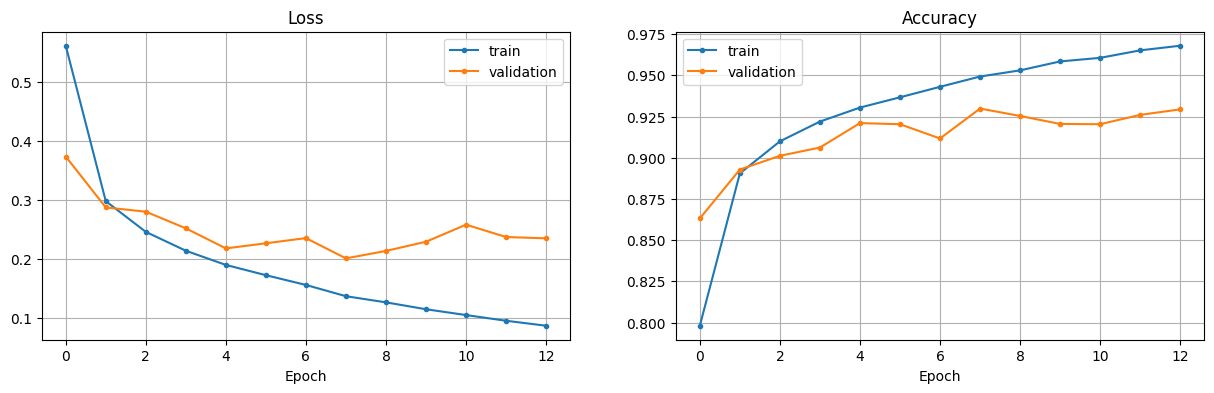

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Best: `Epoch[7]: train_loss=0.1362  val_loss=0.2005  train_acc=0.9493  val_acc=0.9298`

#### Learning rate schedulers

I'm out of all limits on my Collabs, so I am shrinking the scheduler space down.

In [ ]:
def build_model(lr):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    net = keras.applications.MobileNetV2(
        weights=None,
        include_top=True,
        input_shape=(IMG_SIZE, IMG_SIZE, 1),
        classes=10,
    )

    for layer in net.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.momentum = 0.9

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = normalizer(inputs)
    outputs = net(x)
    model = keras.Model(inputs, outputs)

    optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_rand_search_model(hp, epochs):
    name = hp.Choice("scheduler", [
            #"constant",          # baseline: flat 0.0006, for comparison
            "custom_stairs",     # custom staircase
            #"exponential",       # smooth *0.9 per epoch
            #"cosine",            # glide 0.0006 -> ~0 over the whole run
            #"cosine_restarts",   # cosine, but periodically jumps back up (escapes basins)
            #"inverse_time",      # 1/(1+decay*t)
            "piecewise",         # gentler staircase: /10 at epoch 10, /100 at 15
        ])

    base  = 0.001
    steps = len(train_loader)          # batches per epoch
    S     = keras.optimizers.schedules

    if name == "custom_stairs":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 8, steps * 9, steps * 11],
                                      values=[base, 1e-4, 1e-5, 1e-6])
    # elif name == "exponential":
    #     lr = S.ExponentialDecay(base, decay_steps=steps, decay_rate=0.9)
    # elif name == "cosine":
    #     lr = S.CosineDecay(base, decay_steps=steps * epochs)
    # elif name == "cosine_restarts":
    #     lr = S.CosineDecayRestarts(base, first_decay_steps=steps * 10)
    # elif name == "inverse_time":
    #     lr = S.InverseTimeDecay(base, decay_steps=steps, decay_rate=0.5)
    elif name == "piecewise":
        lr = S.PiecewiseConstantDecay(boundaries=[steps * 8, steps * 12],
                                      values=[base, base * 0.1, base * 0.01])
    # else: # "constant"
    #     lr = base

    model = build_model(lr=lr)
    return model

keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

# train_loader / valid_loader come from the prep block above (tr_ds / va_ds)
train_loader = DataLoader(tr_ds, batch_size=125, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(va_ds, batch_size=125, shuffle=False)

sched_tuner = kt.GridSearch(
    functools.partial(build_rand_search_model, epochs=30),
    objective="val_accuracy",
    directory="fine_tuning_lr_schedulers_task_3",
    project_name="fashion_mnist_schedulers",
    seed=RANDOM_SEED,
    overwrite=True,
)
sched_tuner.search(x=train_loader, validation_data=valid_loader, epochs=30,
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                            restore_best_weights=True, verbose=1)],
                   verbose=1, shuffle=False)

Trial 2 Complete [00h 30m 46s]
val_accuracy: 0.9411666393280029

Best val_accuracy So Far: 0.9411666393280029
Total elapsed time: 01h 01m 35s


In [ ]:
debug_tuner(sched_tuner)

,trial_id,score,scheduler
0,0000,0.941167,custom_stairs
1,0001,0.941167,piecewise


New best score: `0.941167`. Visualizing the best model

In [ ]:
def build_model(steps):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    net = keras.applications.MobileNetV2(
        weights=None,
        include_top=True,
        input_shape=(IMG_SIZE, IMG_SIZE, 1),
        classes=10,
    )

    for layer in net.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.momentum = 0.9

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = normalizer(inputs)
    outputs = net(x)
    model = keras.Model(inputs, outputs)

    base = 0.001
    optimizer_obj = keras.optimizers.RMSprop(learning_rate=keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=[steps * 8, steps * 12],
                                      values=[base, base * 0.1, base * 0.01]))

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

# train_loader / valid_loader come from the prep block above (tr_ds / va_ds)
train_loader = DataLoader(tr_ds, batch_size=125, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(va_ds, batch_size=125, shuffle=False)

steps = len(train_loader)
tuned_model = build_model(steps)

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 134s 310ms/step - accuracy: 0.7981 - loss: 0.5616 - val_accuracy: 0.8632 - val_loss: 0.3734
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 147s 341ms/step - accuracy: 0.8905 - loss: 0.2977 - val_accuracy: 0.8928 - val_loss: 0.2870
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 130s 302ms/step - accuracy: 0.9099 - loss: 0.2455 - val_accuracy: 0.9012 - val_loss: 0.2797
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 131s 302ms/step - accuracy: 0.9219 - loss: 0.2134 - val_accuracy: 0.9062 - val_loss: 0.2515
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 131s 304ms/step - accuracy: 0.9304 - loss: 0.1894 - val_accuracy: 0.9210 - val_loss: 0.2174
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 137s 317ms/step - accuracy: 0.9366 - loss: 0.1719 - val_accuracy: 0.9203 - val_loss: 0.2261
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 133s 309ms/step - accuracy: 0.9430 - loss: 0.1554 - val_accuracy: 0.9117 - val_loss: 0.2349
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 131s 303ms/step - accuracy: 0.9493 -

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.5616  val_loss=0.3734  train_acc=0.7981  val_acc=0.8632
Epoch  1: train_loss=0.2977  val_loss=0.2870  train_acc=0.8905  val_acc=0.8928
Epoch  2: train_loss=0.2455  val_loss=0.2797  train_acc=0.9099  val_acc=0.9012
Epoch  3: train_loss=0.2134  val_loss=0.2515  train_acc=0.9219  val_acc=0.9062
Epoch  4: train_loss=0.1894  val_loss=0.2174  train_acc=0.9304  val_acc=0.9210
Epoch  5: train_loss=0.1719  val_loss=0.2261  train_acc=0.9366  val_acc=0.9203
Epoch  6: train_loss=0.1554  val_loss=0.2349  train_acc=0.9430  val_acc=0.9117
Epoch  7: train_loss=0.1362  val_loss=0.2005  train_acc=0.9493  val_acc=0.9298
Epoch  8: train_loss=0.0754  val_loss=0.1821  train_acc=0.9724  val_acc=0.9412
Epoch  9: train_loss=0.0480  val_loss=0.2035  train_acc=0.9835  val_acc=0.9383
Epoch 10: train_loss=0.0311  val_loss=0.2287  train_acc=0.9897  val_acc=0.9360
Epoch 11: train_loss=0.0189  val_loss=0.2634  train_acc=0.9943  val_acc=0.9365
Epoch 

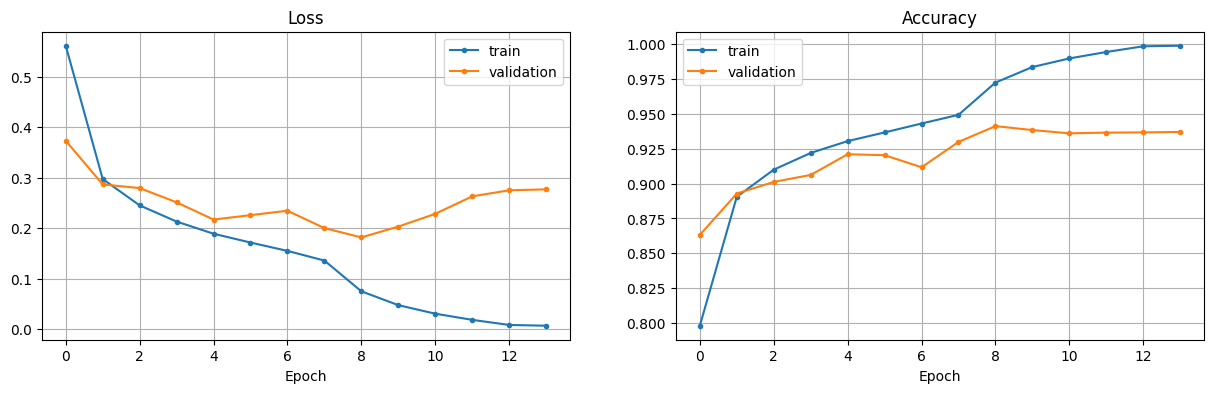

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Indeed best: `Epoch[8]: train_loss=0.0754  val_loss=0.1821  train_acc=0.9724  val_acc=0.9412`

### Best final model and evaluation

Fit on full train before assessing on test:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

full_train_loader = DataLoader(full_train_ds_96, batch_size=125, shuffle=True, generator=torch_gen)
test_loader_96 = DataLoader(test_ds_96, batch_size=125, shuffle=False)

steps = len(full_train_loader)
model = build_model(steps)

history = model.fit(
    x=full_train_loader,
    epochs=9,
    verbose=1,
    shuffle=False,
)

Epoch 1/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 140s 290ms/step - accuracy: 0.8037 - loss: 0.5379
Epoch 2/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 139s 290ms/step - accuracy: 0.8943 - loss: 0.2879
Epoch 3/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 139s 289ms/step - accuracy: 0.9117 - loss: 0.2385
Epoch 4/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 139s 290ms/step - accuracy: 0.9236 - loss: 0.2075
Epoch 5/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 139s 290ms/step - accuracy: 0.9319 - loss: 0.1846
Epoch 6/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 138s 289ms/step - accuracy: 0.9397 - loss: 0.1664
Epoch 7/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 140s 293ms/step - accuracy: 0.9449 - loss: 0.1487
Epoch 8/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 140s 291ms/step - accuracy: 0.9506 - loss: 0.1348
Epoch 9/9
480/480 ━━━━━━━━━━━━━━━━━━━━ 139s 290ms/step - accuracy: 0.9728 - loss: 0.0763


Smoothed scores over epochs grouped by folds:



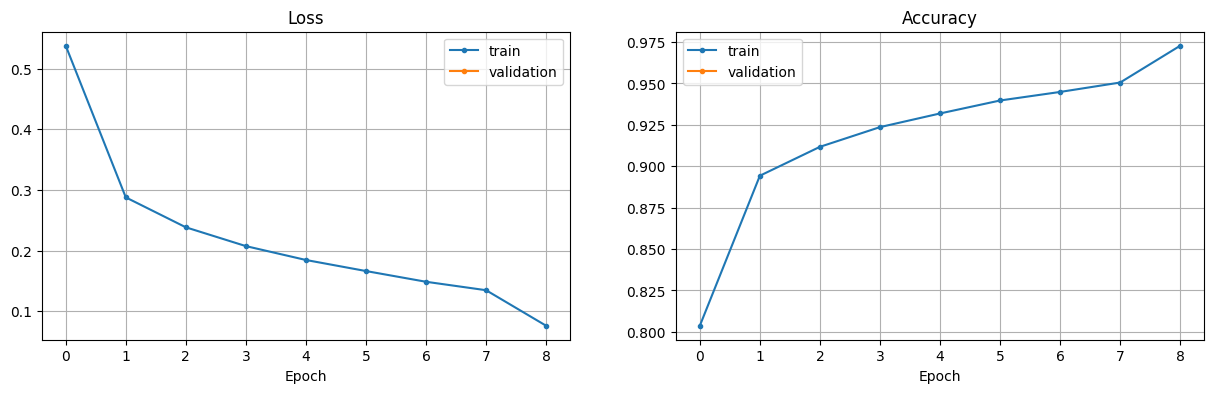

In [ ]:
plot_loss_acc_per_ep(history.history["loss"],     [],
                     history.history["accuracy"], [])

In [ ]:
test_loss, test_acc = model.evaluate(test_loader_96, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.9406 - loss: 0.1922

FINAL TEST ACCURACY: 94.06%
FINAL TEST LOSS:     0.1922


The best test result so far:
- Accuracy: 94.06%
- Loss: 0.1922

In [ ]:
# --- Save (Keras 3 native: architecture + weights + optimizer state in one file) ---
model.save("task3_final_full_train.keras")

# --- Load ---
loaded = keras.models.load_model("task3_final_full_train.keras")

              precision    recall  f1-score   support

 T-shirt/top     0.8922    0.9020    0.8971      1000
     Trouser     0.9940    0.9920    0.9930      1000
    Pullover     0.9083    0.9210    0.9146      1000
       Dress     0.9381    0.9550    0.9465      1000
        Coat     0.9186    0.9140    0.9163      1000
      Sandal     0.9899    0.9820    0.9859      1000
       Shirt     0.8386    0.8000    0.8188      1000
     Sneaker     0.9682    0.9750    0.9716      1000
         Bag     0.9822    0.9920    0.9871      1000
  Ankle boot     0.9720    0.9730    0.9725      1000

    accuracy                         0.9406     10000
   macro avg     0.9402    0.9406    0.9403     10000
weighted avg     0.9402    0.9406    0.9403     10000



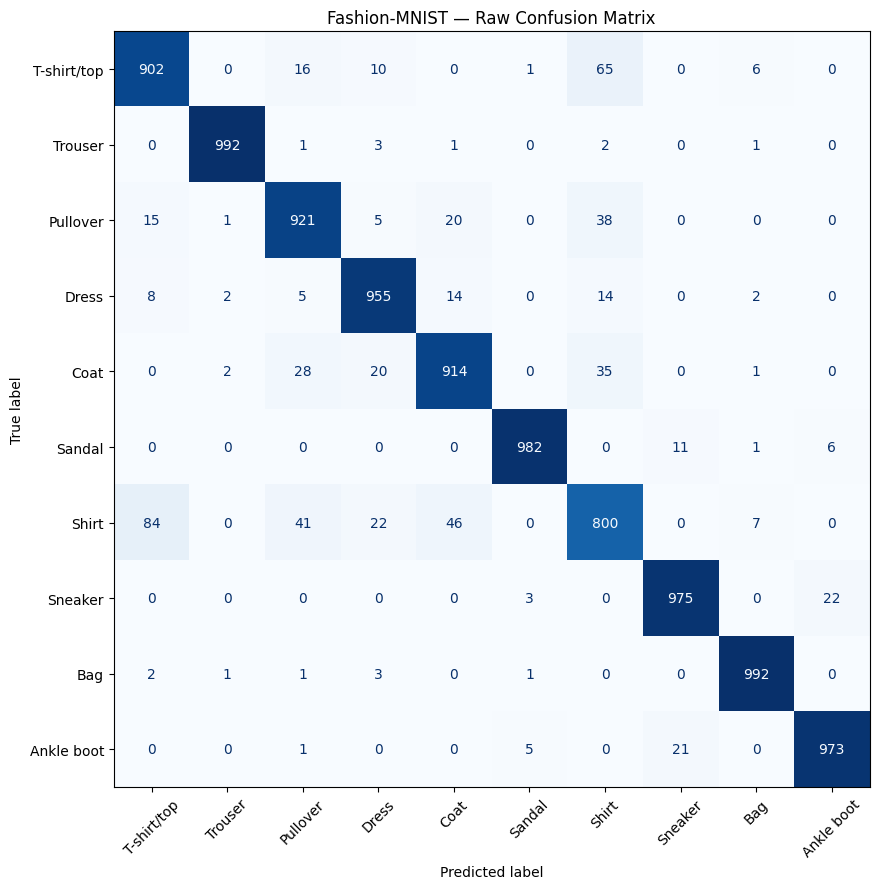

In [ ]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# --- 1. Predictions + true labels out of the DataLoader ---
y_prob = model.predict(test_loader_96, verbose=0)          # (10000, 10) softmax probabilities
y_pred = y_prob.argmax(axis=1)                          # most probable class indices
y_true = np.concatenate([yb.numpy() for _, yb in test_loader_96])  # convert each y_batch from tensor to numpy and concatenate into 1D array

# --- 2. Per-class metrics ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 3. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # integer format
    xticks_rotation=45,
)
ax.set_title("Fashion-MNIST — Raw Confusion Matrix")
plt.tight_layout()
plt.show()

Random sampling tells us little about the accuracy. It is just a sanity check to ensure nothing's broken with the alignment. Realistically, 20 samples isn't enough to assess. That's why the most confident mistakes are plotted. Those are the confusions the model is certain about - this what explains its most vulnerabilities.

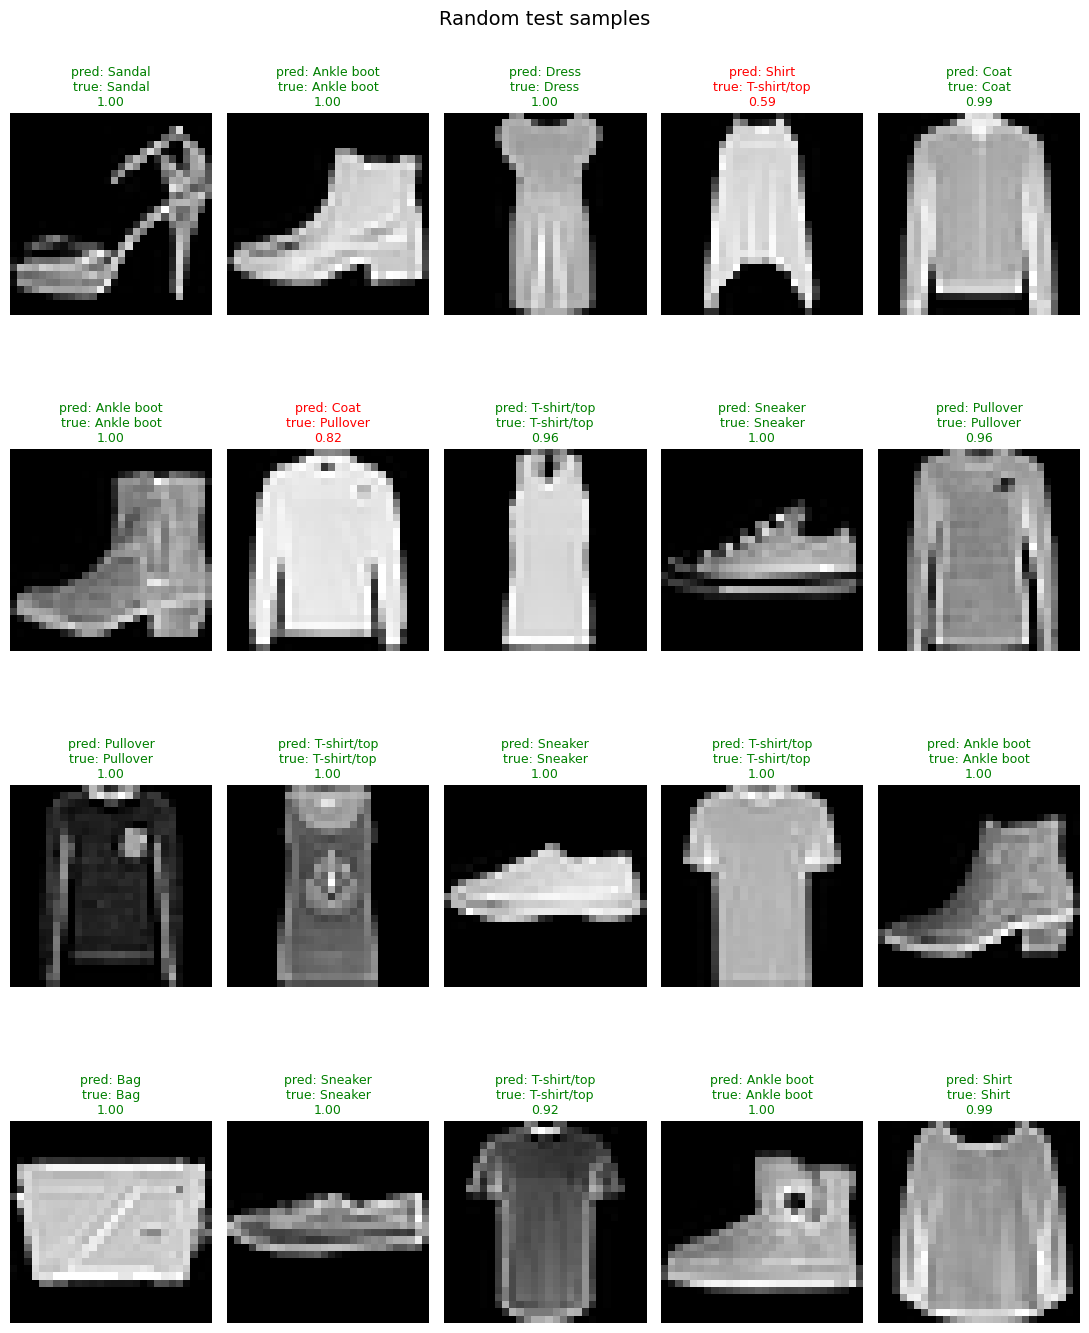

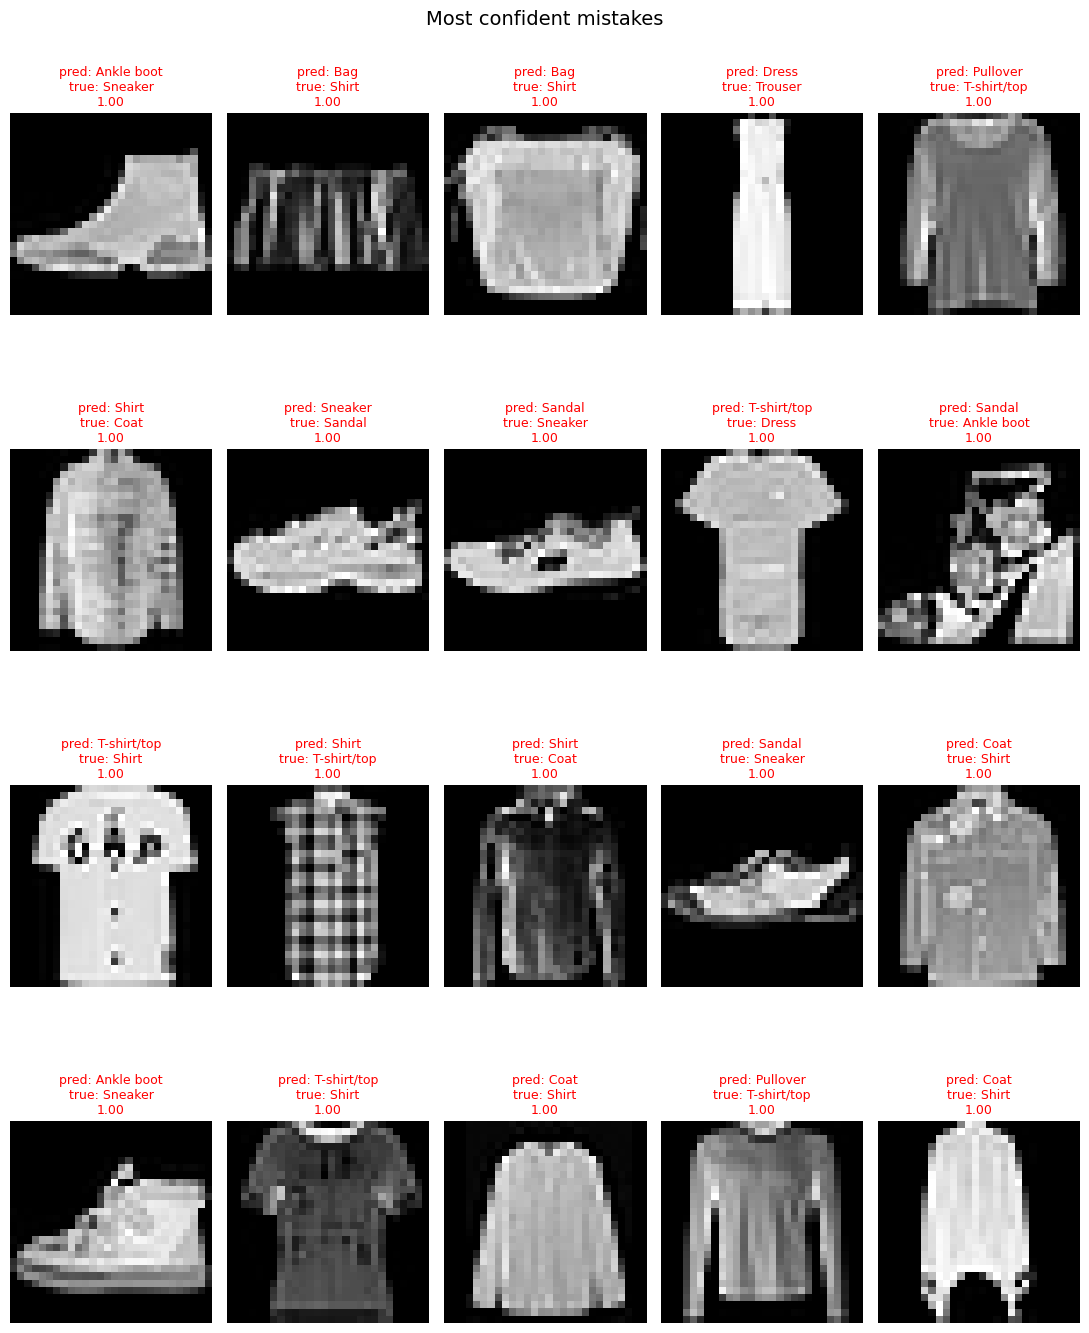

In [ ]:
# --- 4. Visual check: predicted vs true ---
assert np.array_equal(y_true, y_test), "loader order != X_test order"   # shuffle=False guarantees this

confidence = y_prob.max(axis=1)          # softmax prob of the predicted class

def show_predictions(indices, title, n_cols=5):
    n_rows = int(np.ceil(len(indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 3.6 * n_rows))
    for ax, i in zip(np.ravel(axes), indices):
        ax.imshow(X_test[i], cmap="gray")            # original 28x28, not the upscaled one
        ok = y_pred[i] == y_true[i]
        ax.set_title(
            f"pred: {CLASS_NAMES[y_pred[i]]}\ntrue: {CLASS_NAMES[y_true[i]]}\n{confidence[i]:.2f}",
            fontsize=9, color=("green" if ok else "red"),
        )
        ax.axis("off")
    for ax in np.ravel(axes)[len(indices):]:         # blank out unused cells
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


rng_vis = np.random.default_rng(RANDOM_SEED)

# (a) a random sample - what the model does on average
show_predictions(rng_vis.choice(len(y_true), size=20, replace=False),
                 "Random test samples")

# (b) the confident mistakes - where the model is wrong AND sure of itself
wrong = np.flatnonzero(y_pred != y_true)
worst = wrong[np.argsort(-confidence[wrong])][:20]
show_predictions(worst, "Most confident mistakes")

## Conclusion

Three models were built for the same task, each representing one branch of the
transfer-learning decision framework established in `Task 2`.

| | Model | Params | Input | Test acc | Test loss |
| :-- | :-- | --: | :-- | --: | --: |
| `Task 1` | Custom 4-block CNN, from scratch | 1,261,133 | 28×28×1 | 93.44% | 0.1877 |
| `Task 2` | VGG16 pre-trained, block 5 fine-tuned | 14,714,688 (base) | 96×96×3 | 93.35% | 0.1942 |
| `Task 3` | MobileNetV2, `weights=None` | 2,270,218 | 96×96×1 | **94.06%** | 0.1922 |

**On the framework.** Our case was diagnosed as *large data* + *far domain* + *architecture unsuited to the input*, which points to Option 2 — train from scratch. The experiment confirms the diagnosis. `Task 2`'s frozen VGG16 saturated at $87.78\%$ validation as a linear probe, and even after unfreezing block 5 it only reached parity with a model 12× smaller. Pre-trained ImageNet features bought us nothing here; the entire `Task 2` result came from the ~7.1M parameters we retrained, not from what was inherited.

**On the ceiling.** `Task 3` exceeding `Task 1` by 0.62pp means we had *not* reached the data ceiling at 93.44% — extra capacity still bought something. However, the comparison is confounded: `Task 3` changed the architecture (depth, inverted residuals, skip connections), the input resolution (28→96), and the optimizer (Adam→RMSprop) simultaneously. The gain cannot be attributed to any one of these. A clean test would hold the input at 28×28 and vary only depth.

All three confusion matrices concentrate error in the same place: *T-shirt/top*, *Pullover*, *Coat*, *Shirt* — four classes sharing an upper-body silhouette, separable only by sleeve length, collar shape, buttons, and weave. That information is not present in 28×28 grayscale, and bilinear upsampling to 96×96 does not create it. This is why three architectures spanning 1.2M–14.7M parameters, two of them ImageNet-pretrained, all land within 0.7pp of each other. The limit is the input resolution, not the model.